# 6B &mdash; Evaluation of *Experiment B* (complete dataset, main contribution)

This notebook evaluates **Experiment B**: the noise-injection runs stored under
`complete_experiments/Experiment_B`. Experiment B is the **main focus** of the
thesis (see `CLAUDE.md`): it uses the **complete** (non feature-reduced)
dataset and a much wider grid of **up to 20 random seeds**, so its conclusions
carry real statistical weight.

Experiment B is organised into two scenarios:

* **`Pucktrick_on_single_feature/`** &mdash; noise injected into *one* feature/column
  at a time (plus a `labels_experiment/` sub-folder that corrupts the target
  labels instead of features);
* **`Pucktrick_on_multiple_features/`** &mdash; noise injected into *several*
  features simultaneously (work in progress).

The loader records this as a `scenario` column (`single` / `multi`) so the same
analysis serves both.

> **Note.** This notebook is written to run *before* the runs are finished. If a
> section finds no data yet it says so and moves on. As the experiment folder
> fills up, **Restart &amp; Run All** refreshes every result, tightening the
> confidence intervals automatically as more seeds land.

---

### What this notebook does (and why)

The evaluation is **completely dynamic**: it discovers every
`*_artifacts.json` under the experiment folder and recomputes all tables,
plots and confidence intervals from scratch on every run. The structure mirrors
notebook `6A` but adds the single- vs. multiple-feature `scenario` dimension.

| Section | Question it answers | Why it matters for the thesis |
|---|---|---|
| 1. Dynamic loading | What runs exist on disk? | Reproducible, self-updating basis for everything below. |
| 2. Coverage | How many seeds back each cell? | A CI over few seeds &ne; a CI over 20; reported honestly. |
| 3. Leaderboard (mean &plusmn; CI) | Headline numbers per scenario | Thesis-ready estimates with uncertainty. |
| 4. Metric vs. noise level | For each feature, how do **F1** and **MCC** evolve as noise grows, per method? | Central research question. |
| 5. Heatmaps | Where does noise help vs. hurt? | Compact manuscript figures. |
| 6. Paired significance | Are observed changes real? | Supports causal *improvement* claims over many seeds. |
| 7. Model comparison | TabNet vs. CNN-LSTM robustness | Architectural insight. |
| 8. Per-class analysis | Which attack classes benefit / suffer? | Macro metrics hide rare-class effects. |
| 9. Feature-importance drift | Does corruption change feature reliance? | Mechanistic explanation. |
| 10. Export | LaTeX/CSV artefacts | Drop-in tables for `temp-latex`. |
| 11. Auto-summary | Written digest with key numbers | Seed for the chapter conclusions. |

*Note on language:* the narrative is written in English so it can be lifted
straight into the (English) thesis in `temp-latex`.


In [21]:
# --- imports & configuration -------------------------------------------------
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import experiment_eval_utils as eu   # shared helpers (see experiment_eval_utils.py)

# ---- knobs you may want to change ------------------------------------------
PHASE        = 'B'                  # "A" or "B"
ROOT_DIR     = 'complete_experiments/Experiment_B'
CONF_LEVEL   = 0.95                       # confidence level for all CIs
RESULTS_DIR  = "evaluation_results/Experiment_B"   # CSV/figure exports
SAVE_FIGURES = False                      # True -> also write PNGs under RESULTS_DIR/figures

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Phase            : Experiment", PHASE)
print("Reading from     :", ROOT_DIR)
print("Confidence level :", CONF_LEVEL)
print("Exports ->       :", RESULTS_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Phase            : Experiment B
Reading from     : complete_experiments/Experiment_B
Confidence level : 0.95
Exports ->       : evaluation_results/Experiment_B


## 1. Dynamic data loading

`load_experiment_dataframe` walks the experiment tree and turns every artifact
into **two tidy rows** (one for the *binary* task, one for the *multiclass*
task). Every downstream table and figure is derived from this single
`DataFrame`, so the whole notebook stays consistent and refreshes together.

Each artifact stores the metrics (`accuracy`, `f1`, `mcc`, `auc`) per task; the
experimental coordinates (model / method / corrupted feature / noise %) are
parsed from the file name.

In [22]:
df = eu.load_experiment_dataframe(ROOT_DIR)
df.head()

[load] 8082/8084 artifact files parsed (0 skipped, 2 baselines handled separately) -> 16164 task-rows.
       models   : ['cnn_lstm', 'tabnet']
       methods  : ['duplicated', 'labels', 'missing', 'noise', 'outliers']
       features : ['Bwd Byts_b Avg', 'Dst Port', 'Fwd Act Data Pkts', 'Fwd Blk Rate Avg', 'Fwd Seg Size Min', 'Idle Mean', 'Init Fwd Win Byts', 'Label', 'PSH Flag Cnt', 'Protocol', 'Timestamp', 'label_generic']
       noise %  : [np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(35.0), np.float64(50.0), np.float64(75.0)]
       seeds    : [np.int64(1), np.int64(11), np.int64(21), np.int64(31), np.int64(41), np.int64(42), np.int64(51), np.int64(61), np.int64(86), np.int64(101), np.int64(202), np.int64(303), np.int64(404), np.int64(505), np.int64(606), np.int64(707), np.int64(808), np.int64(909), np.int64(1010), np.int64(1111)]
       scenarios: ['single']


,model,method,feature,noise_percentage,seed,scenario,is_labels_variant,task,n_classes,path,accuracy,f1,mcc,auc
0,cnn_lstm,duplicated,Timestamp,10.0,1,single,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.937256,0.778187,0.763718,0.934216
1,cnn_lstm,duplicated,Timestamp,10.0,1,single,False,multiclass,13,complete_experiments/Experiment_B/Pucktrick_on...,0.908746,0.283399,0.665959,NaN
2,cnn_lstm,duplicated,Timestamp,20.0,1,single,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.936364,0.788485,0.760201,0.944637
3,cnn_lstm,duplicated,Timestamp,20.0,1,single,False,multiclass,13,complete_experiments/Experiment_B/Pucktrick_on...,0.863287,0.182580,0.481546,NaN
4,cnn_lstm,duplicated,Timestamp,35.0,1,single,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.935992,0.773897,0.758375,0.926894


In [23]:
# Experiment B only: quick look at the two scenarios (single vs multiple feature).
if df.empty:
    print("No Experiment B artifacts on disk yet - run the experiments, then re-run this notebook.")
else:
    print("Rows per scenario:")
    display(df.groupby("scenario").size().rename("rows").to_frame())
    print("\nLabels-variant runs (target corruption) per scenario:")
    display(df.groupby(["scenario", "is_labels_variant"]).size().rename("rows").to_frame())

Rows per scenario:


,rows
scenario,
single,16164



Labels-variant runs (target corruption) per scenario:


rows
scenario is_labels_variant       
single   False              14724
         True                1440

In [24]:
# Guard used throughout: if nothing is on disk yet, the rest still runs cleanly.
HAS_DATA = not df.empty
if not HAS_DATA:
    print("[!] No artifacts found - downstream sections will be empty until runs exist.")
    MODELS, TASKS = [], ["binary", "multiclass"]
else:
    MODELS = sorted(df["model"].dropna().unique())
    TASKS  = ["binary", "multiclass"]
    print("Models  :", MODELS)
    print("Methods :", sorted(df["method"].dropna().unique()))
    print("Features:", sorted(df["feature"].dropna().unique()))
    print("Noise % :", sorted(df["noise_percentage"].dropna().unique()))
    print("Seeds   :", sorted(df["seed"].dropna().unique()),
          f"(n={df['seed'].nunique()})")

Models  : ['cnn_lstm', 'tabnet']
Methods : ['duplicated', 'labels', 'missing', 'noise', 'outliers']
Features: ['Bwd Byts_b Avg', 'Dst Port', 'Fwd Act Data Pkts', 'Fwd Blk Rate Avg', 'Fwd Seg Size Min', 'Idle Mean', 'Init Fwd Win Byts', 'Label', 'PSH Flag Cnt', 'Protocol', 'Timestamp', 'label_generic']
Noise % : [np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(35.0), np.float64(50.0), np.float64(75.0)]
Seeds   : [np.int64(1), np.int64(11), np.int64(21), np.int64(31), np.int64(41), np.int64(42), np.int64(51), np.int64(61), np.int64(86), np.int64(101), np.int64(202), np.int64(303), np.int64(404), np.int64(505), np.int64(606), np.int64(707), np.int64(808), np.int64(909), np.int64(1010), np.int64(1111)] (n=20)


### 1b. Clean baseline (0% noise)

The `Baselines/` sub-folder holds the models trained on the **uncorrupted**
dataset (one per model). This is the *genuine* clean reference the noise
experiments are measured against &mdash; earlier versions of this notebook had to
fall back to the lowest available noise level as a proxy. It is loaded
separately (it carries no method/feature/noise coordinates) and is **excluded**
from the noisy-run `DataFrame`, then used as a reference line in the trend plots,
as the centre of the heatmaps, and as the null value in the significance tests
below.

In [25]:
BL = eu.load_baselines(ROOT_DIR)
HAS_BASELINE = not BL.empty
if HAS_BASELINE:
    display(BL[["model", "task", "accuracy", "f1", "mcc", "auc"]]
            .round(4).reset_index(drop=True))
else:
    print("[!] No clean baseline found under Baselines/ - "
          "plots fall back to the lowest-noise proxy reference.")

[baseline] loaded 2 baseline file(s) -> models=['cnn_lstm', 'tabnet']


,model,task,accuracy,f1,mcc,auc
0,cnn_lstm,binary,0.9307,0.7593,0.7373,0.9204
1,cnn_lstm,multiclass,0.9002,0.2525,0.6352,NaN
2,tabnet,binary,0.9677,0.8967,0.8833,0.9730
3,tabnet,multiclass,0.9574,0.5040,0.8558,0.9266


## 2. Coverage &mdash; how trustworthy is each cell?

Before averaging anything we check **how many seeds** actually back each
`(method, feature, noise%)` combination. This is the empirical basis of every
confidence interval below:

* a cell with **1 seed** has *no* CI (reported as `NaN`) and must be read with
  caution;
* cells with uneven seed counts are expected while the grid is still filling in.

Surfacing this keeps the thesis honest: we never present a mean over two runs as
if it were as solid as a mean over twenty.

In [26]:
if HAS_DATA:
    for model in MODELS:
        print(f"\n=== Seed coverage - {model} (binary task) ===")
        cov = eu.coverage_table(df, model, task="binary")
        display(cov.style.background_gradient(cmap="Greens", axis=None))
    seeds_per_cell = (df.groupby(["model", "task", "method", "feature", "noise_percentage"])
                        ["seed"].nunique())
    print("\nSeeds per cell - min / median / max:",
          int(seeds_per_cell.min()), "/", int(seeds_per_cell.median()), "/",
          int(seeds_per_cell.max()))


=== Seed coverage - cnn_lstm (binary task) ===



=== Seed coverage - tabnet (binary task) ===



Seeds per cell - min / median / max: 14 / 20 / 20


## 3. Aggregated results with confidence intervals

`aggregate_with_ci` groups the long table and reports, for every metric,
`mean`, `std`, the seed count `n`, and a **two-sided Student-t confidence
interval** whose width adapts to `n`. Student-t (rather than a normal
approximation) is the right choice for the small seed counts used here.

Below: the headline **MCC** and **F1** per `(model, task, method, feature,
noise%)`, formatted as `mean ± half-CI`.

In [40]:
def leaderboard(metric):
    if not HAS_DATA:
        return pd.DataFrame()
    agg = eu.aggregate_with_ci(
        df, ["model", "task", "method", "feature", "noise_percentage"],
        metric, conf=CONF_LEVEL)
    agg = agg.sort_values("mean", ascending=False)
    agg[f"{metric} (mean +/- CI)"] = [
        eu.format_mean_ci(m, h) for m, h in zip(agg["mean"], agg["ci_half"])]
    return agg

mcc_board = leaderboard("mcc")
if HAS_DATA:
    print("Top-15 configurations by mean MCC:")
    display(mcc_board[["model", "task", "method", "feature", "noise_percentage","n", "mcc (mean +/- CI)"]].reset_index(drop=True))

Top-15 configurations by mean MCC:


,model,task,method,feature,noise_percentage,n,mcc (mean +/- CI)
0,tabnet,binary,outliers,Fwd Act Data Pkts,75.0,20,0.886 ± 0.002
1,tabnet,binary,outliers,Fwd Act Data Pkts,50.0,20,0.885 ± 0.003
2,tabnet,binary,outliers,Fwd Act Data Pkts,10.0,20,0.885 ± 0.003
3,tabnet,binary,noise,Fwd Act Data Pkts,50.0,20,0.885 ± 0.003
4,tabnet,binary,noise,Fwd Act Data Pkts,20.0,20,0.885 ± 0.002
...,...,...,...,...,...,...,...
811,cnn_lstm,multiclass,labels,label_generic,75.0,20,0.099 ± 0.065
812,cnn_lstm,binary,labels,label_generic,50.0,20,0.070 ± 0.114
813,tabnet,binary,labels,label_generic,50.0,20,-0.073 ± 0.041
814,cnn_lstm,binary,labels,label_generic,75.0,20,-0.127 ± 0.094


In [41]:
f1_board = leaderboard("f1")
if HAS_DATA:
    print("Top-15 configurations by mean F1:")
    display(f1_board[["model", "task", "method", "feature", "noise_percentage","n", "f1 (mean +/- CI)"]].reset_index(drop=True))

Top-15 configurations by mean F1:


,model,task,method,feature,noise_percentage,n,f1 (mean +/- CI)
0,cnn_lstm,binary,outliers,Timestamp,50.0,20,0.902 ± 0.008
1,tabnet,binary,outliers,Fwd Act Data Pkts,75.0,20,0.900 ± 0.002
2,tabnet,binary,outliers,Fwd Act Data Pkts,10.0,20,0.899 ± 0.002
3,tabnet,binary,noise,Fwd Act Data Pkts,50.0,20,0.899 ± 0.002
4,tabnet,binary,outliers,Fwd Act Data Pkts,50.0,20,0.899 ± 0.002
...,...,...,...,...,...,...,...
811,cnn_lstm,multiclass,noise,Dst Port,75.0,20,0.164 ± 0.030
812,cnn_lstm,multiclass,outliers,Dst Port,50.0,20,0.163 ± 0.027
813,tabnet,binary,labels,label_generic,50.0,20,0.146 ± 0.018
814,tabnet,binary,labels,label_generic,75.0,20,0.102 ± 0.011


## 4. Core trends &mdash; F1 / MCC vs. noise level, per feature & method

This is the central figure family of the chapter. For each **model** and
**task** we plot the metric (**MCC**, then **F1**) against the **noise level**,
with:

* **one subplot per corrupted feature**,
* **one line per PuckTrick method**,
* a **shaded band** = the Student-t confidence interval across seeds,
* a **dashed horizontal line** = the clean-baseline value for this model/task.

Reading guide: a curve **above** the dashed baseline means that corruption makes
the model *better than training on clean data* (the surprising effect the proof
of concept is after); a curve that *falls* with noise is the intuitive
degradation; flat-within-band means the model is *robust* to that corruption.

(The legend lists every method present anywhere in the figure plus the baseline,
so no curve is omitted even when a method is missing from the first subplot.)

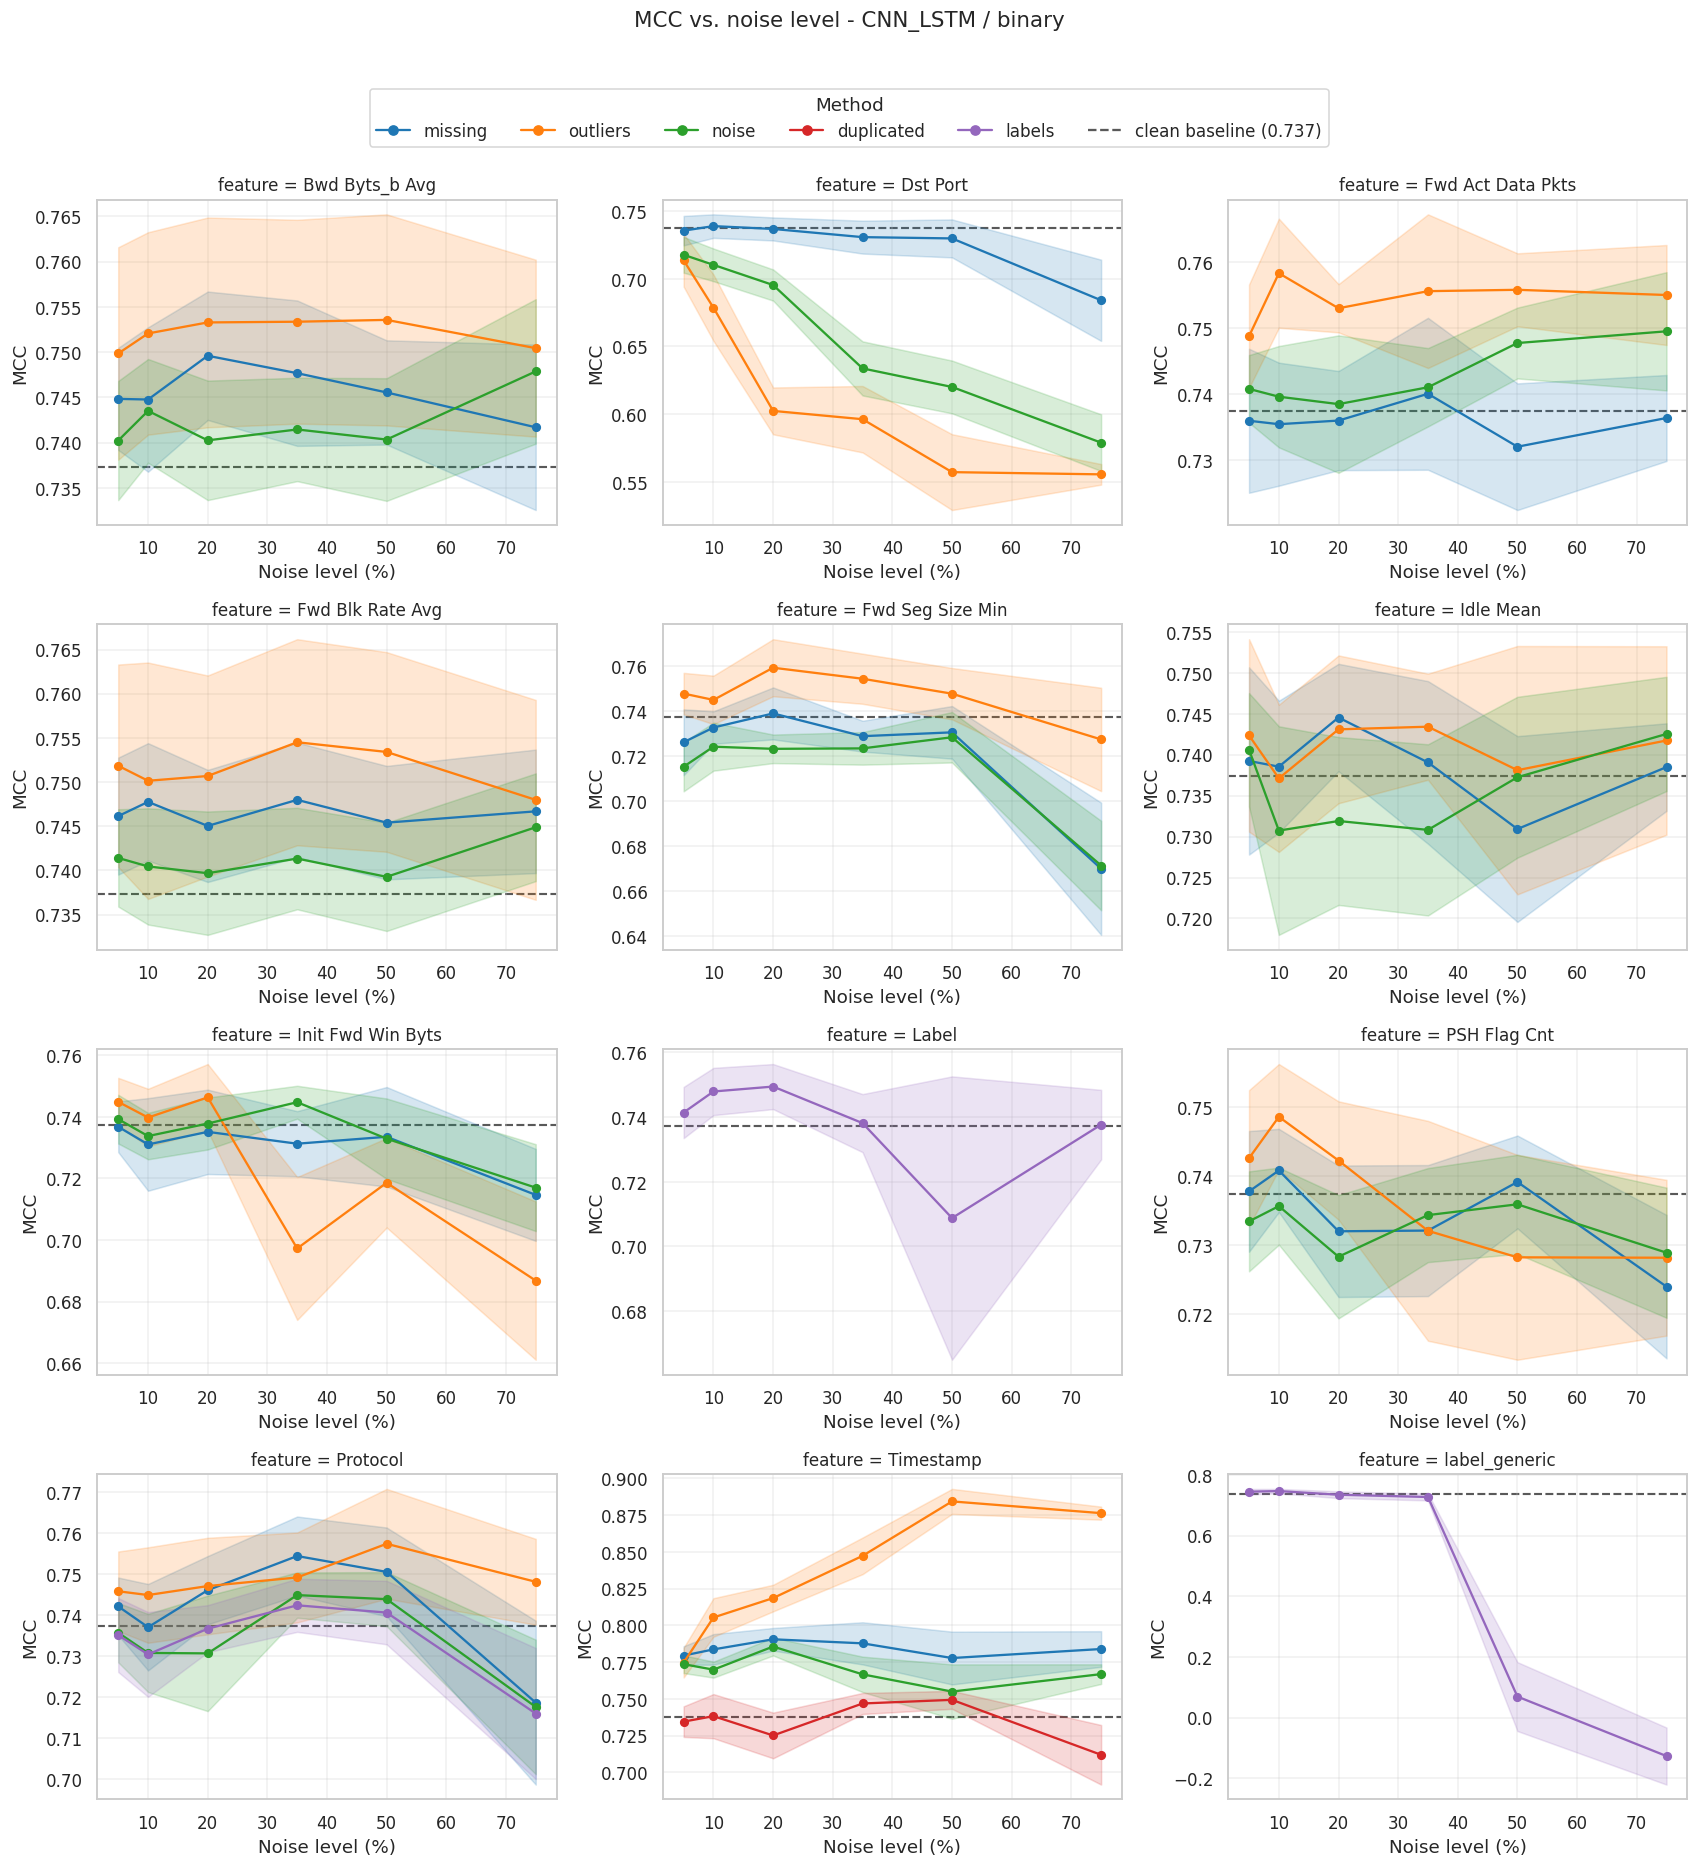

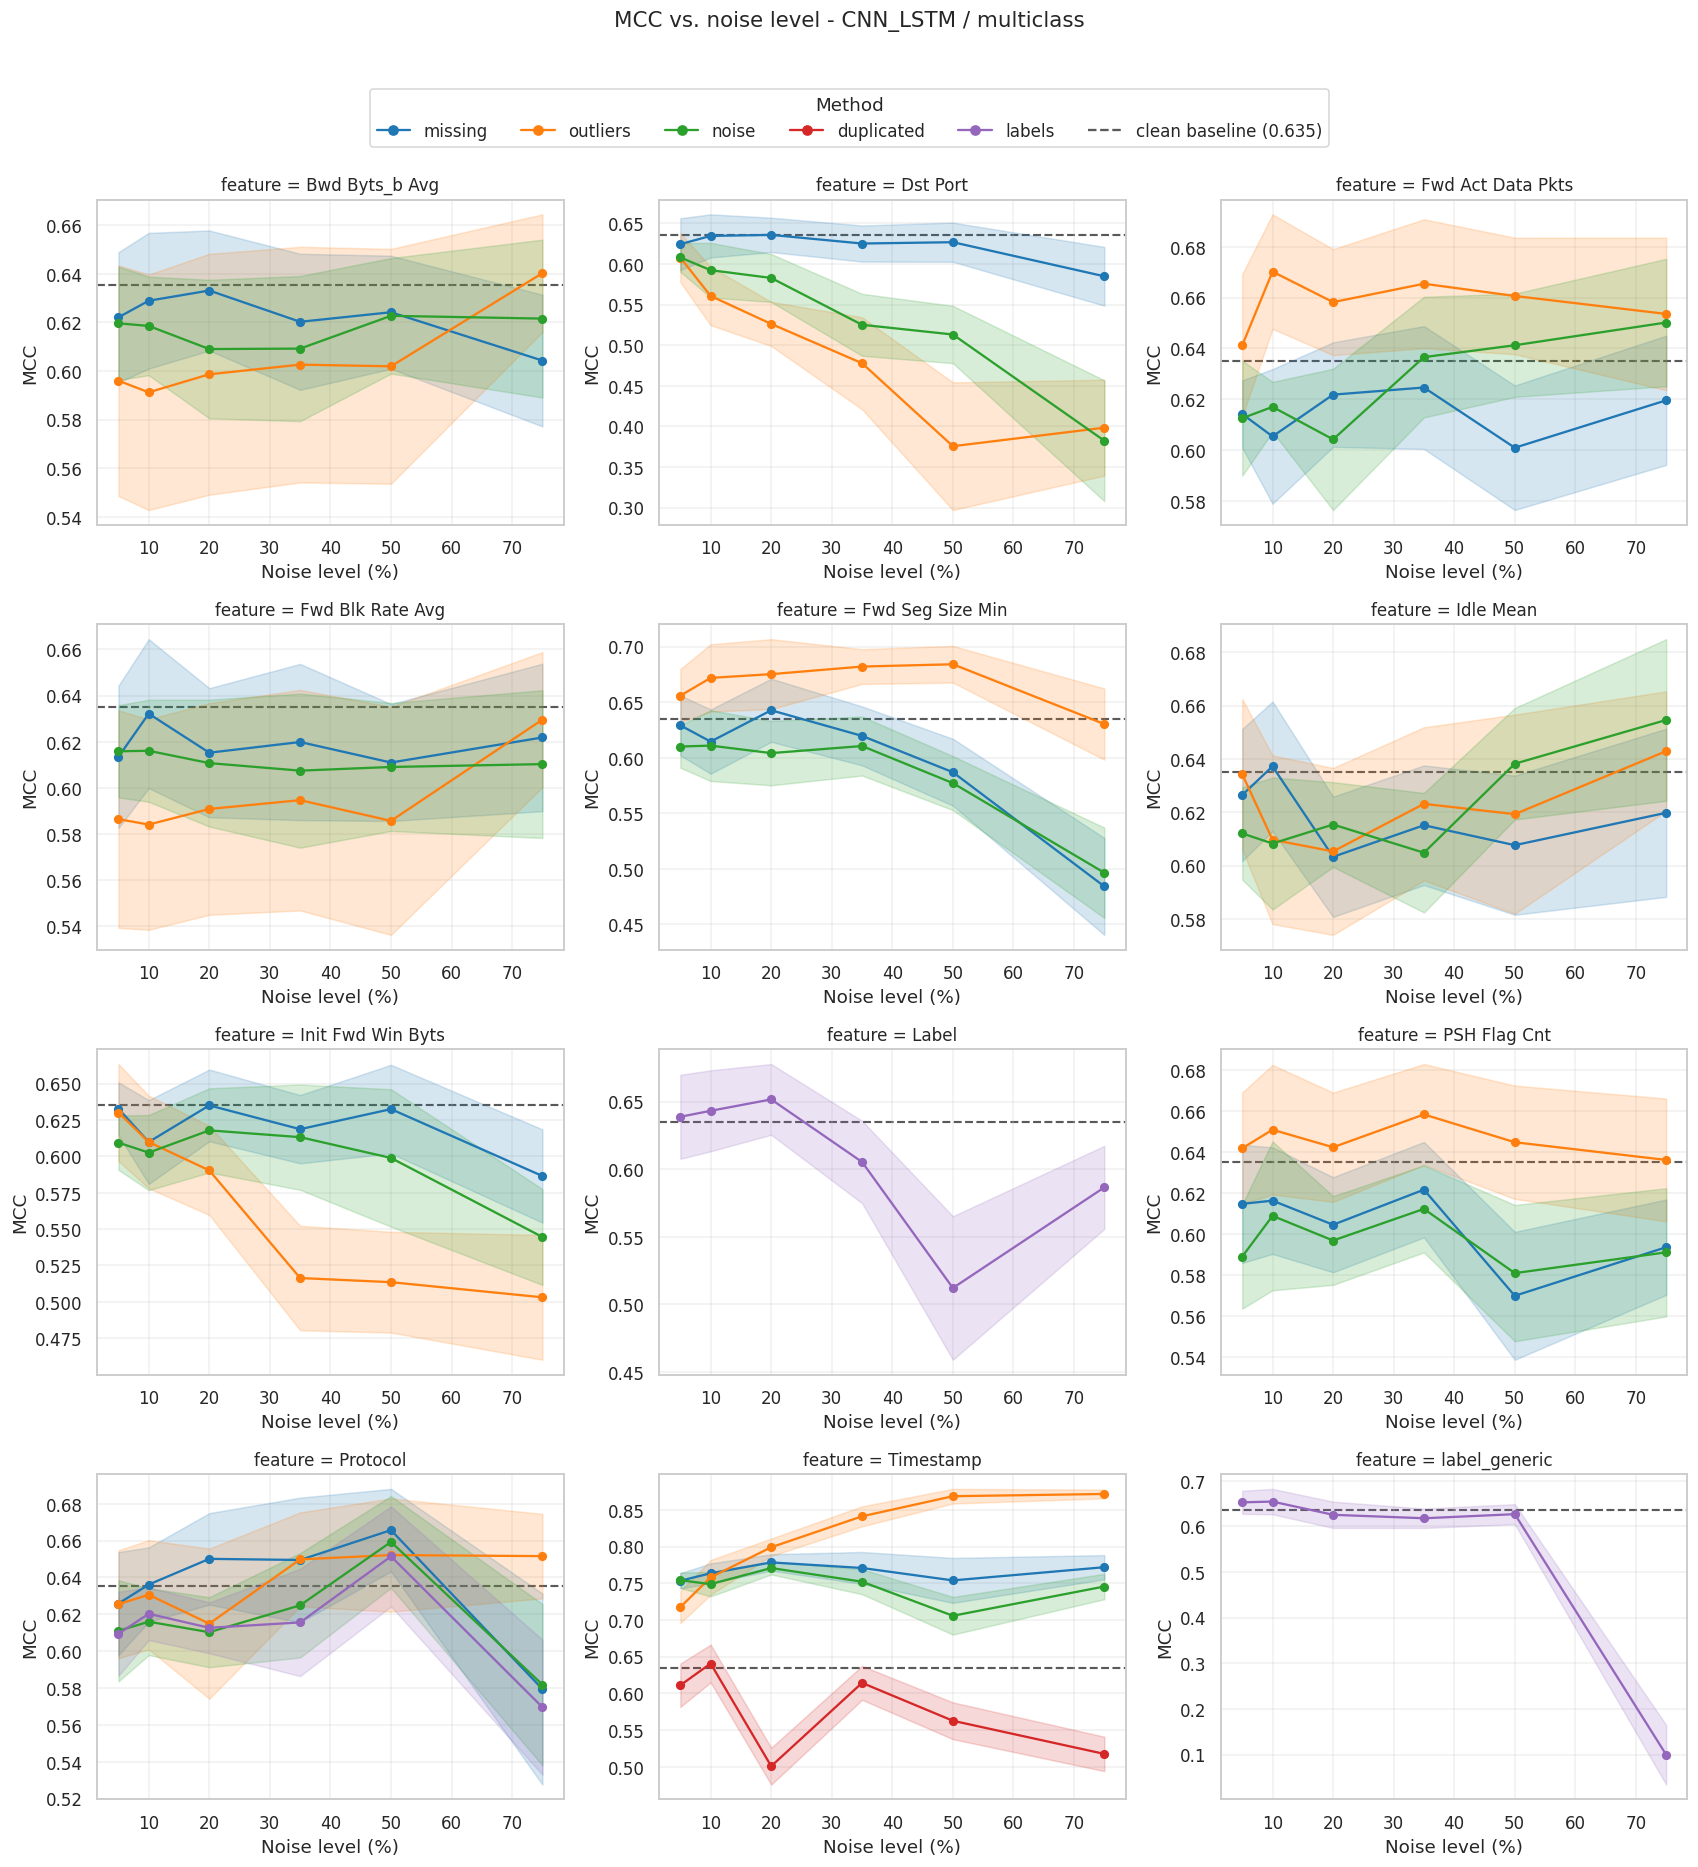

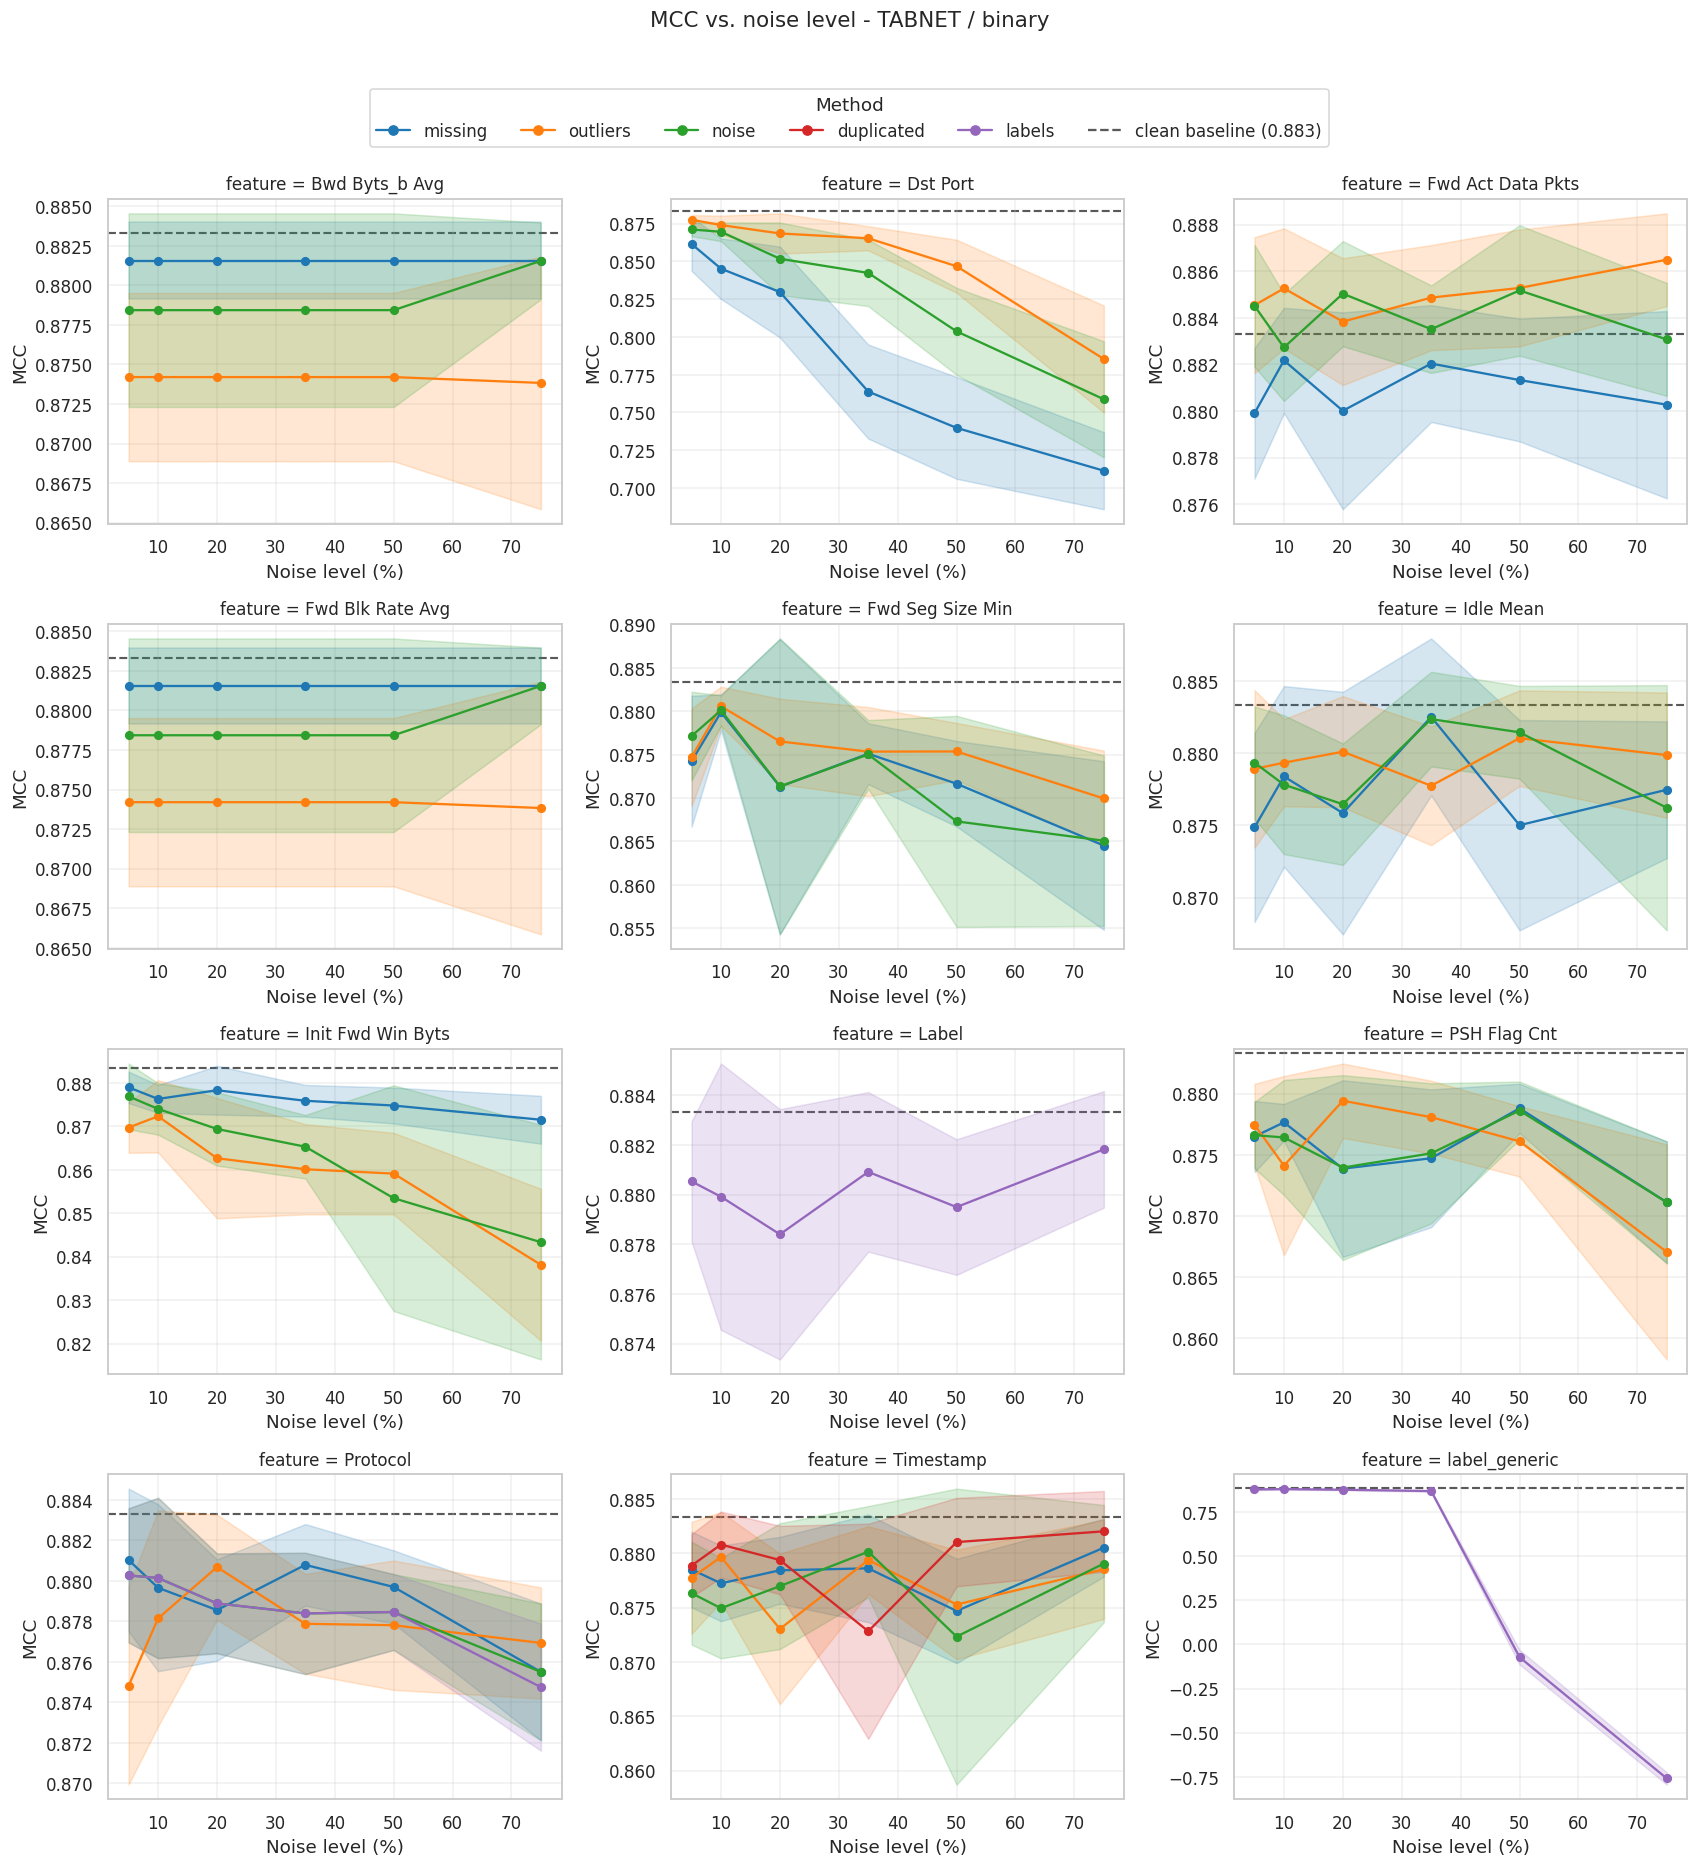

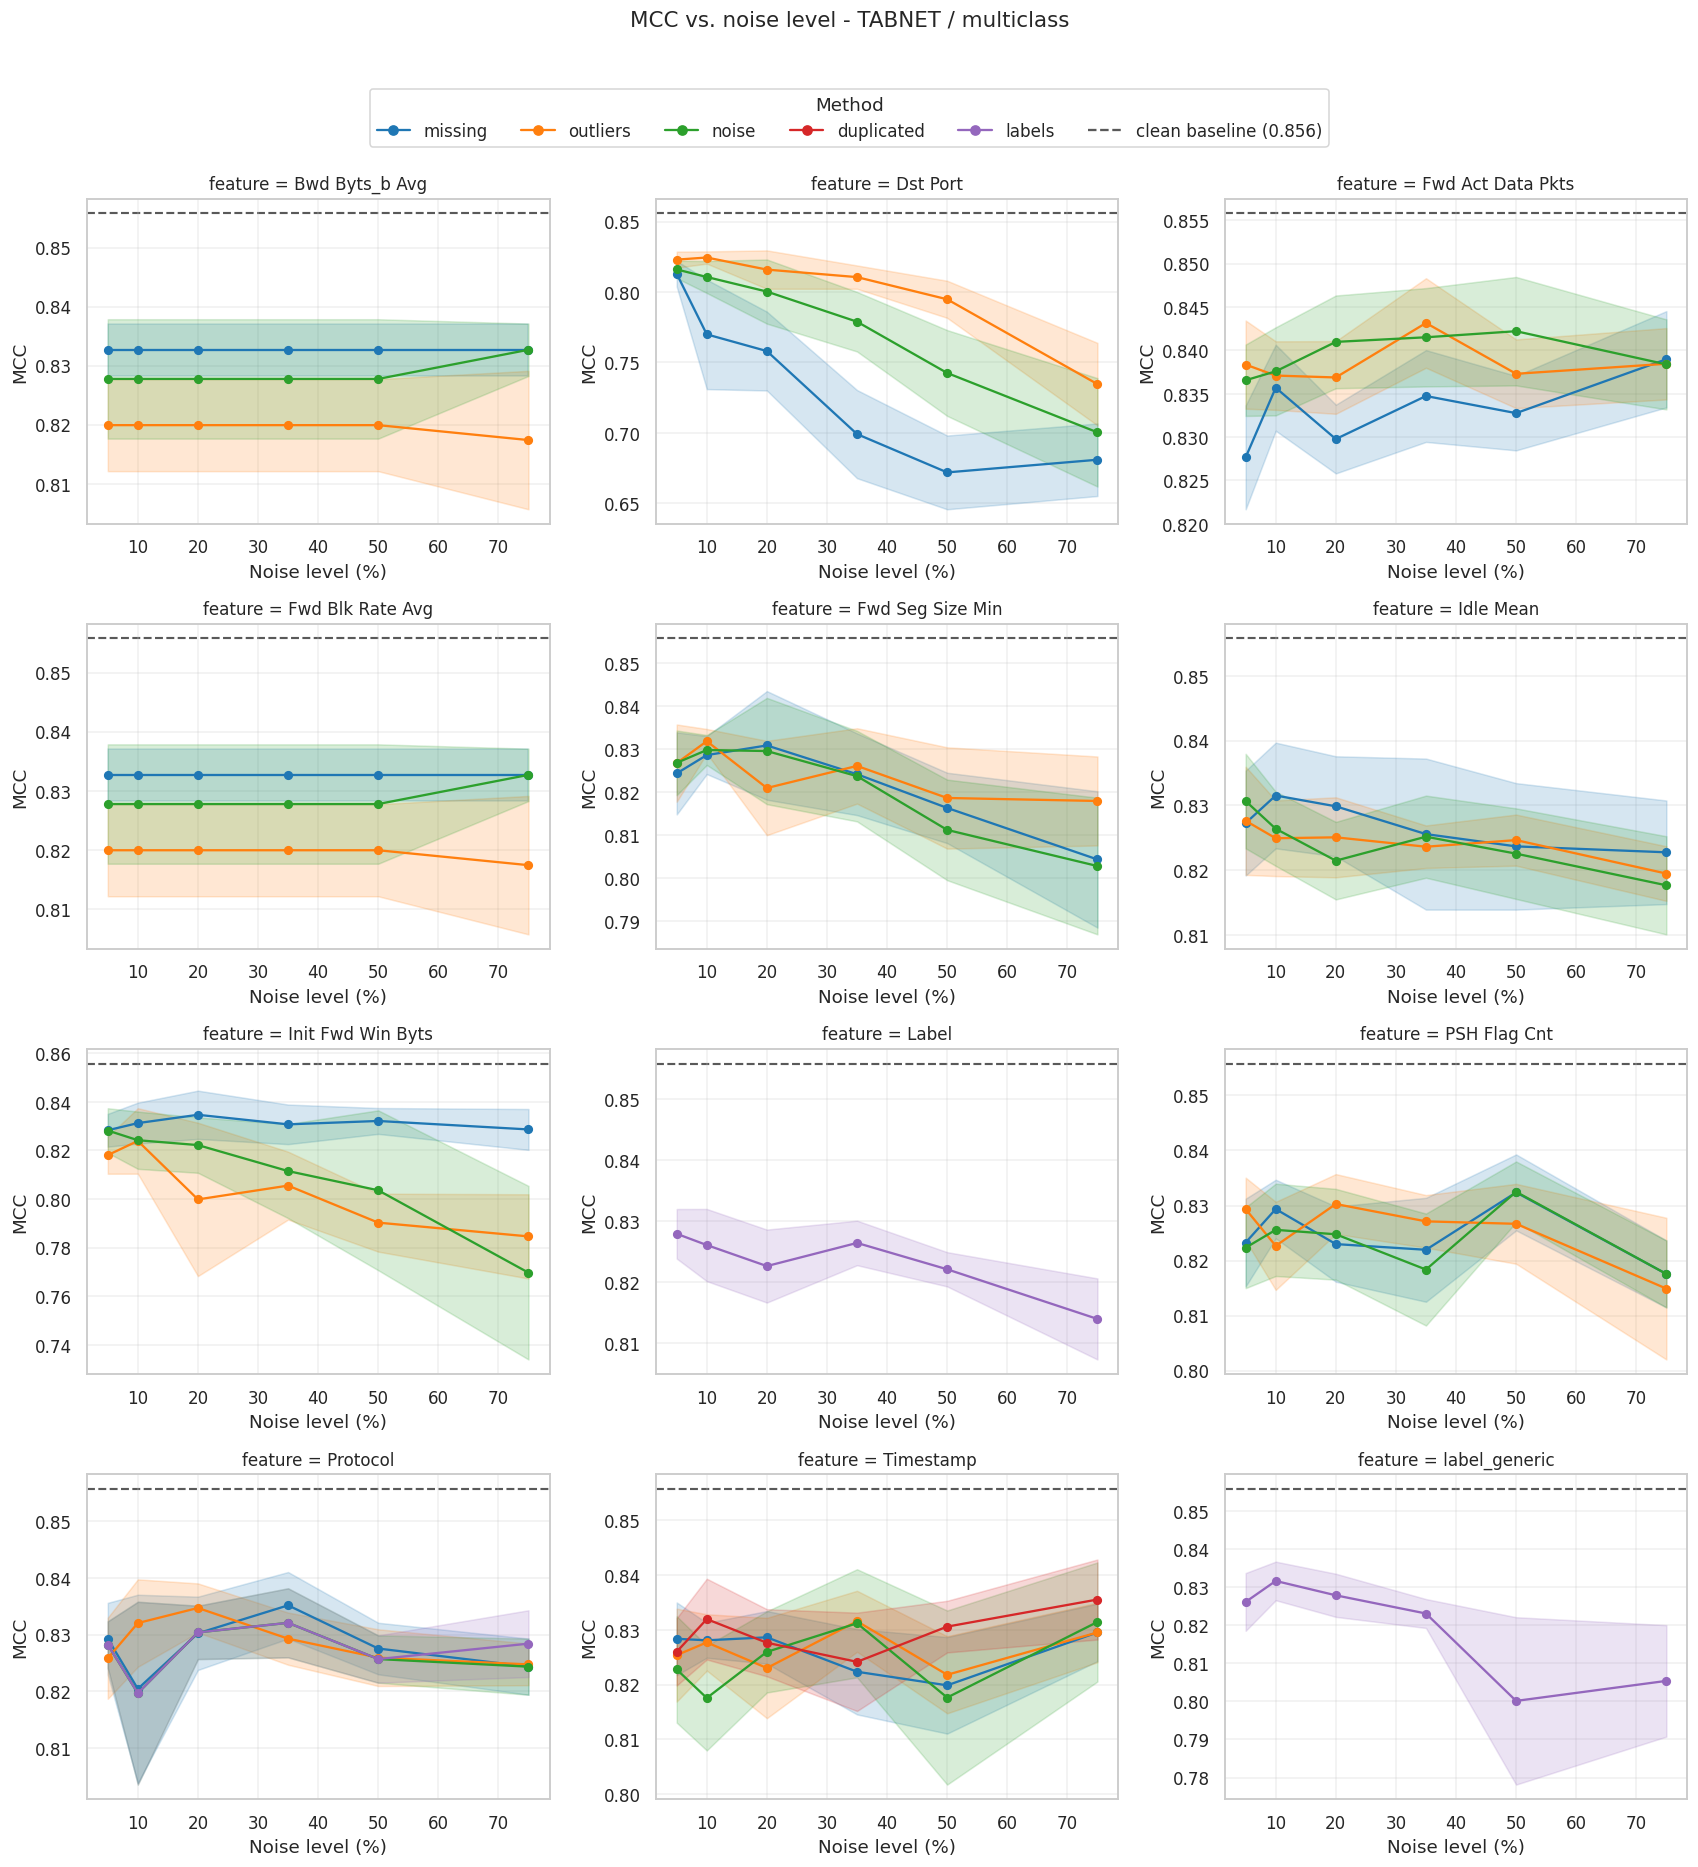

In [29]:
def trend_figs(metric):
    if not HAS_DATA:
        print("No data yet."); return
    for model in MODELS:
        for task in TASKS:
            save = (os.path.join(RESULTS_DIR, "figures",
                                 f"{metric}_{model}_{task}_by_feature.png")
                    if SAVE_FIGURES else None)
            fig = eu.plot_metric_vs_noise(df, model, task, metric,
                                          conf=CONF_LEVEL, facet_by="feature",
                                          hue="method", baselines=BL, savepath=save)
            if fig is not None:
                plt.show()

trend_figs("mcc")

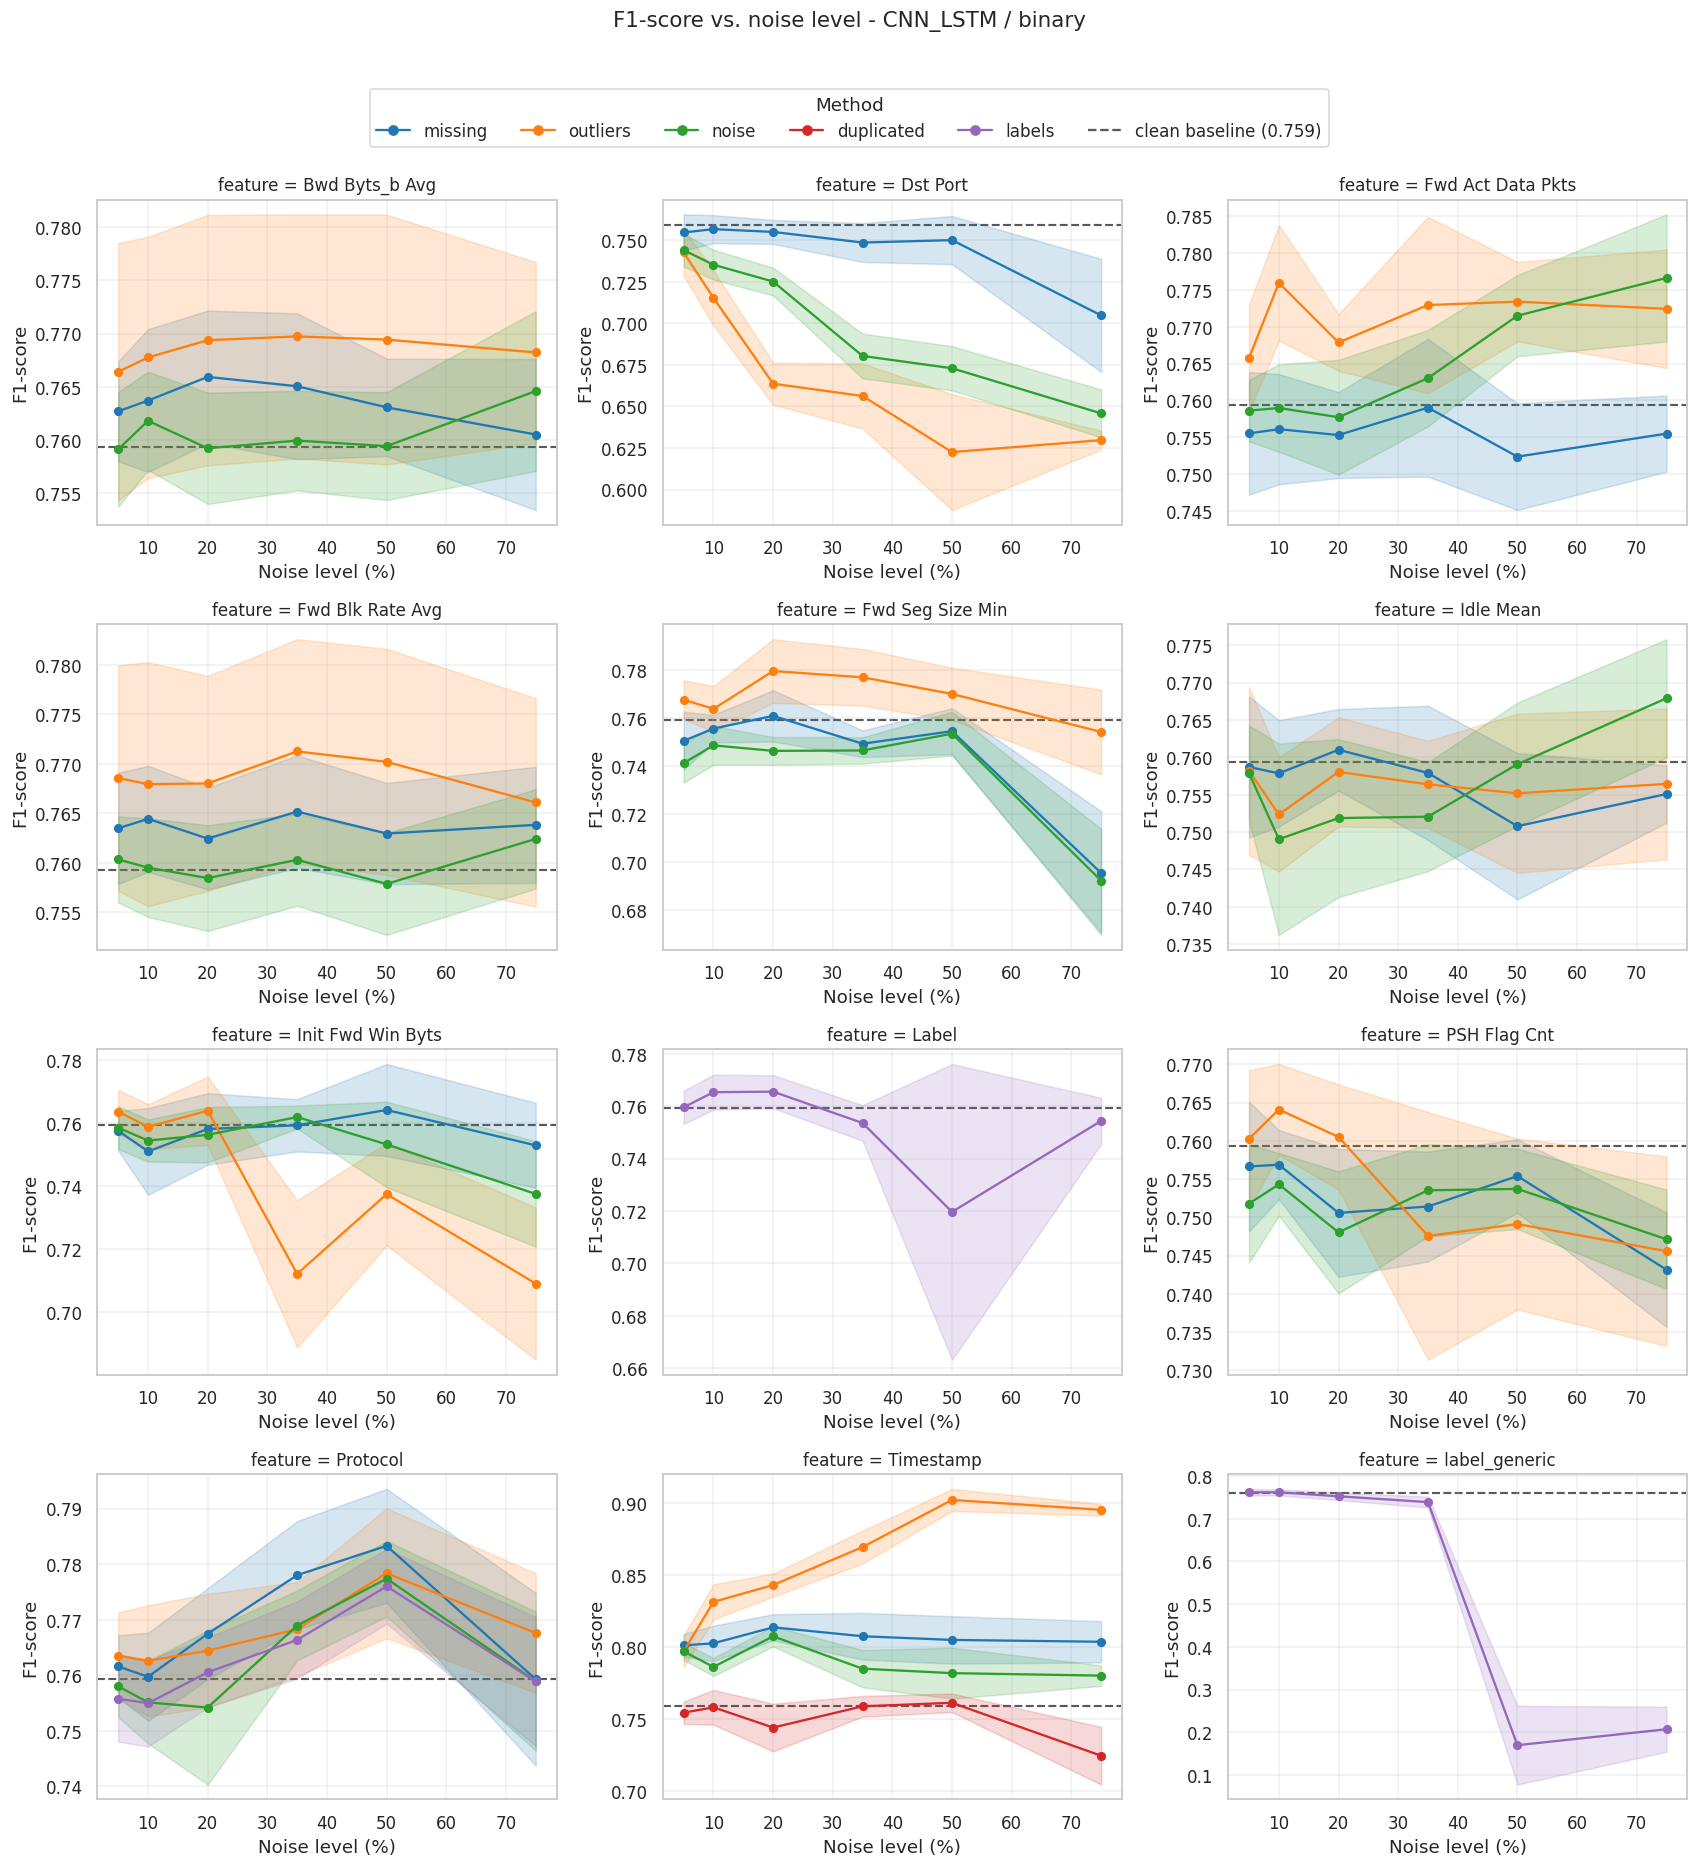

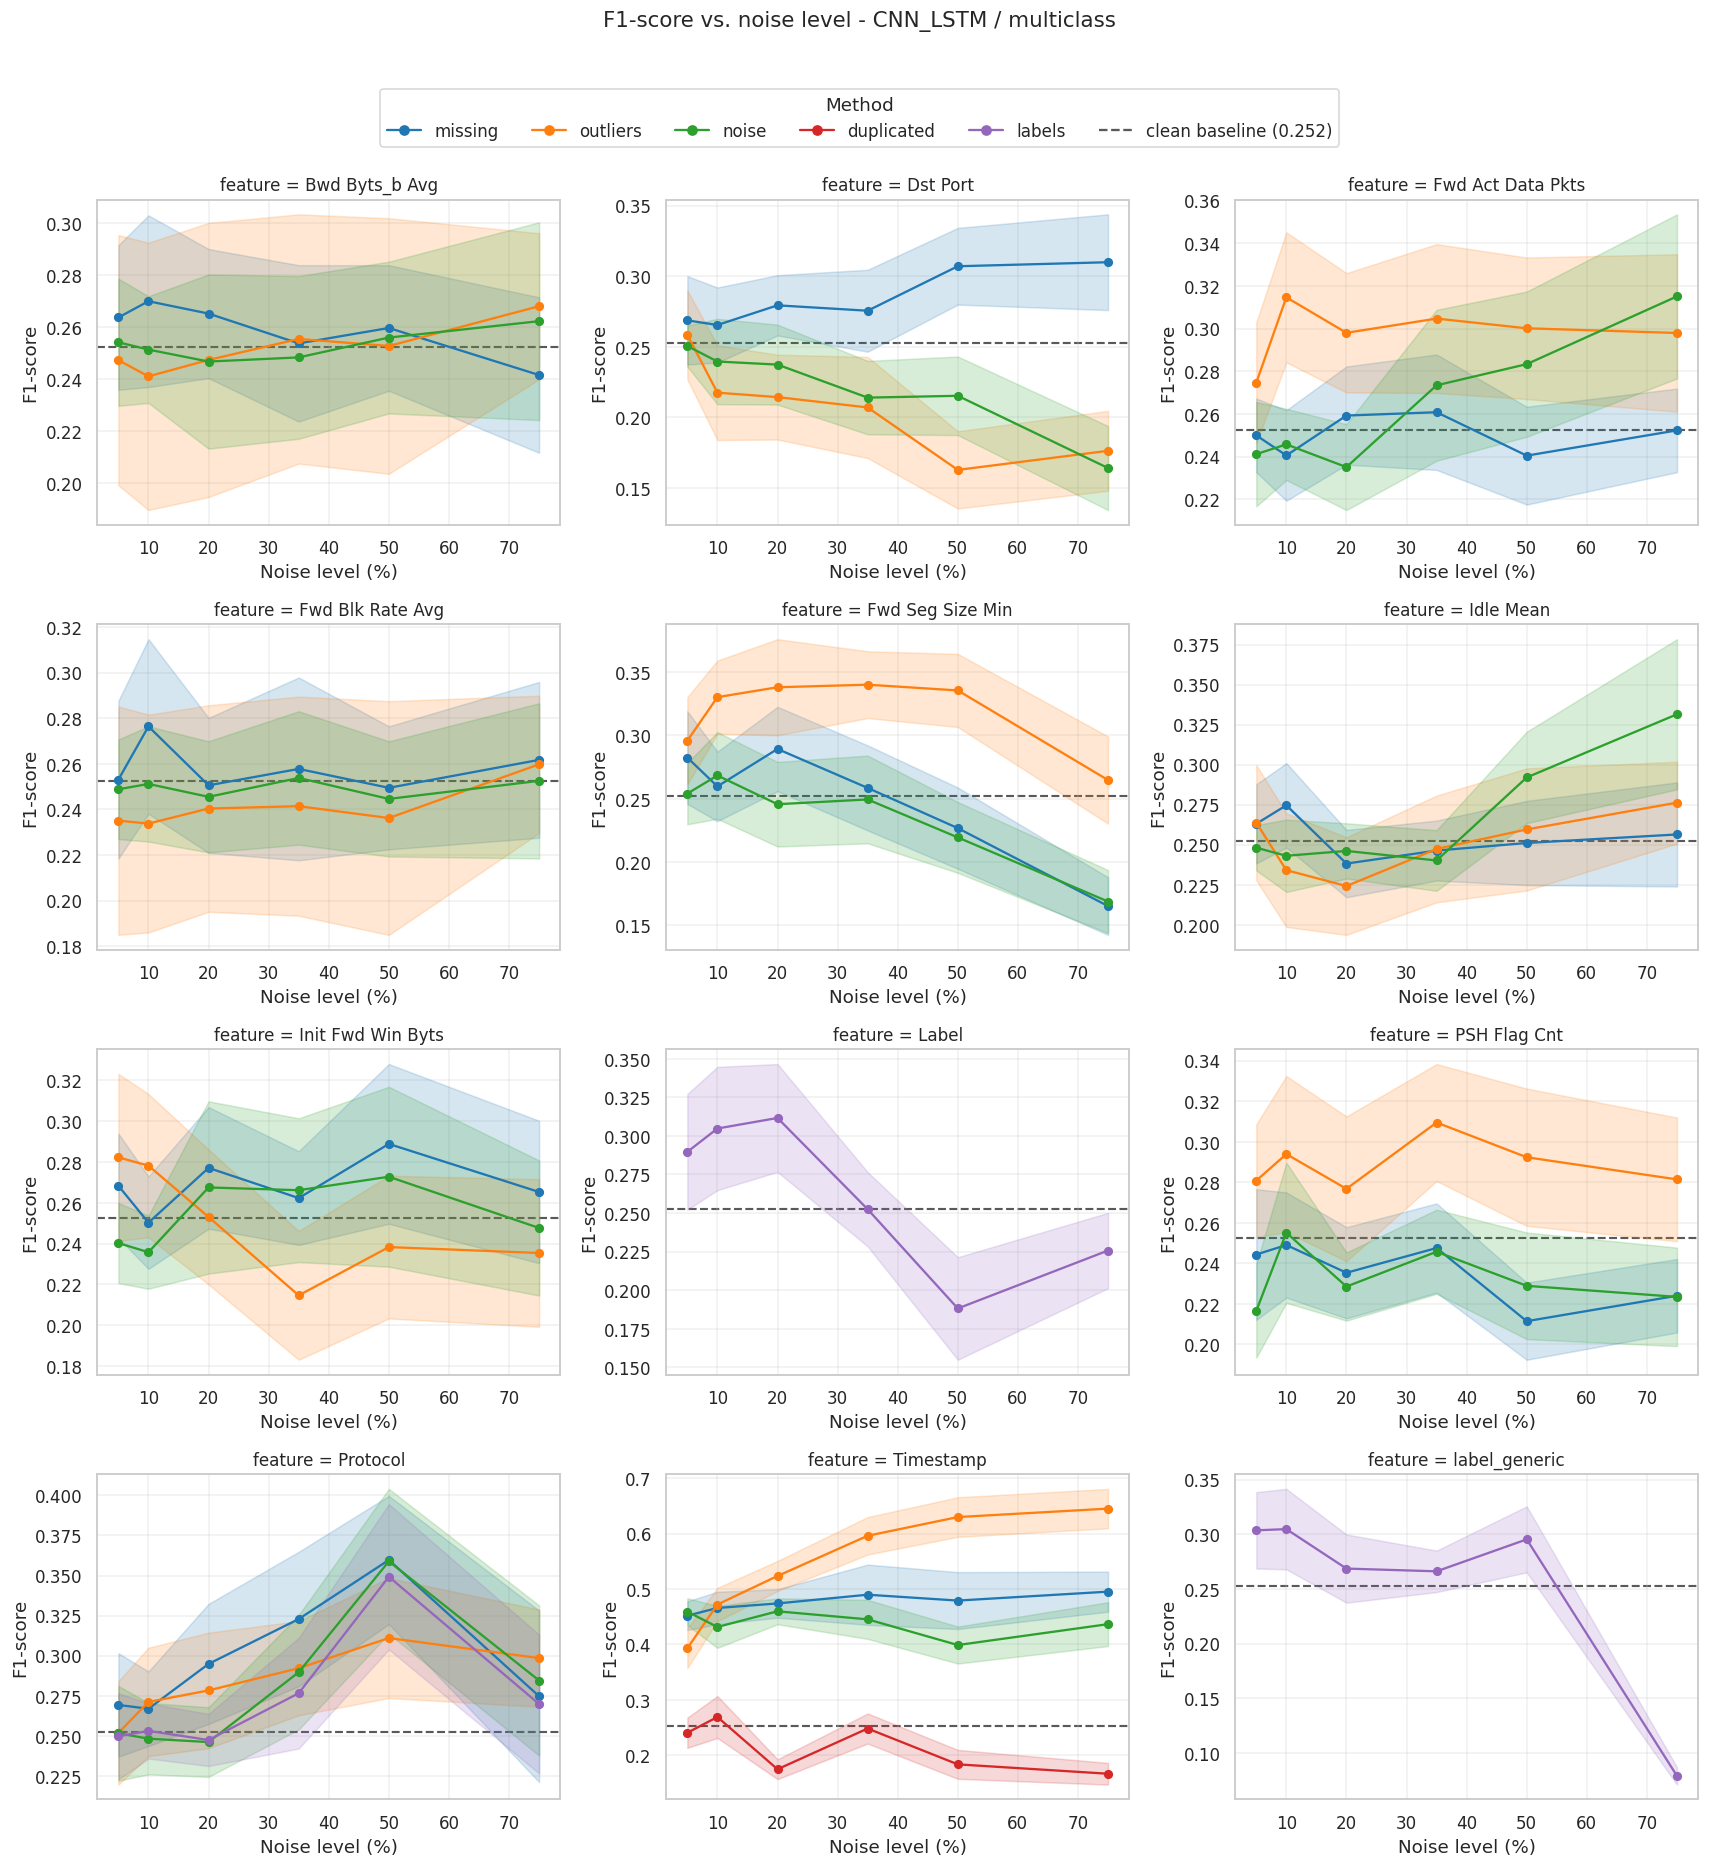

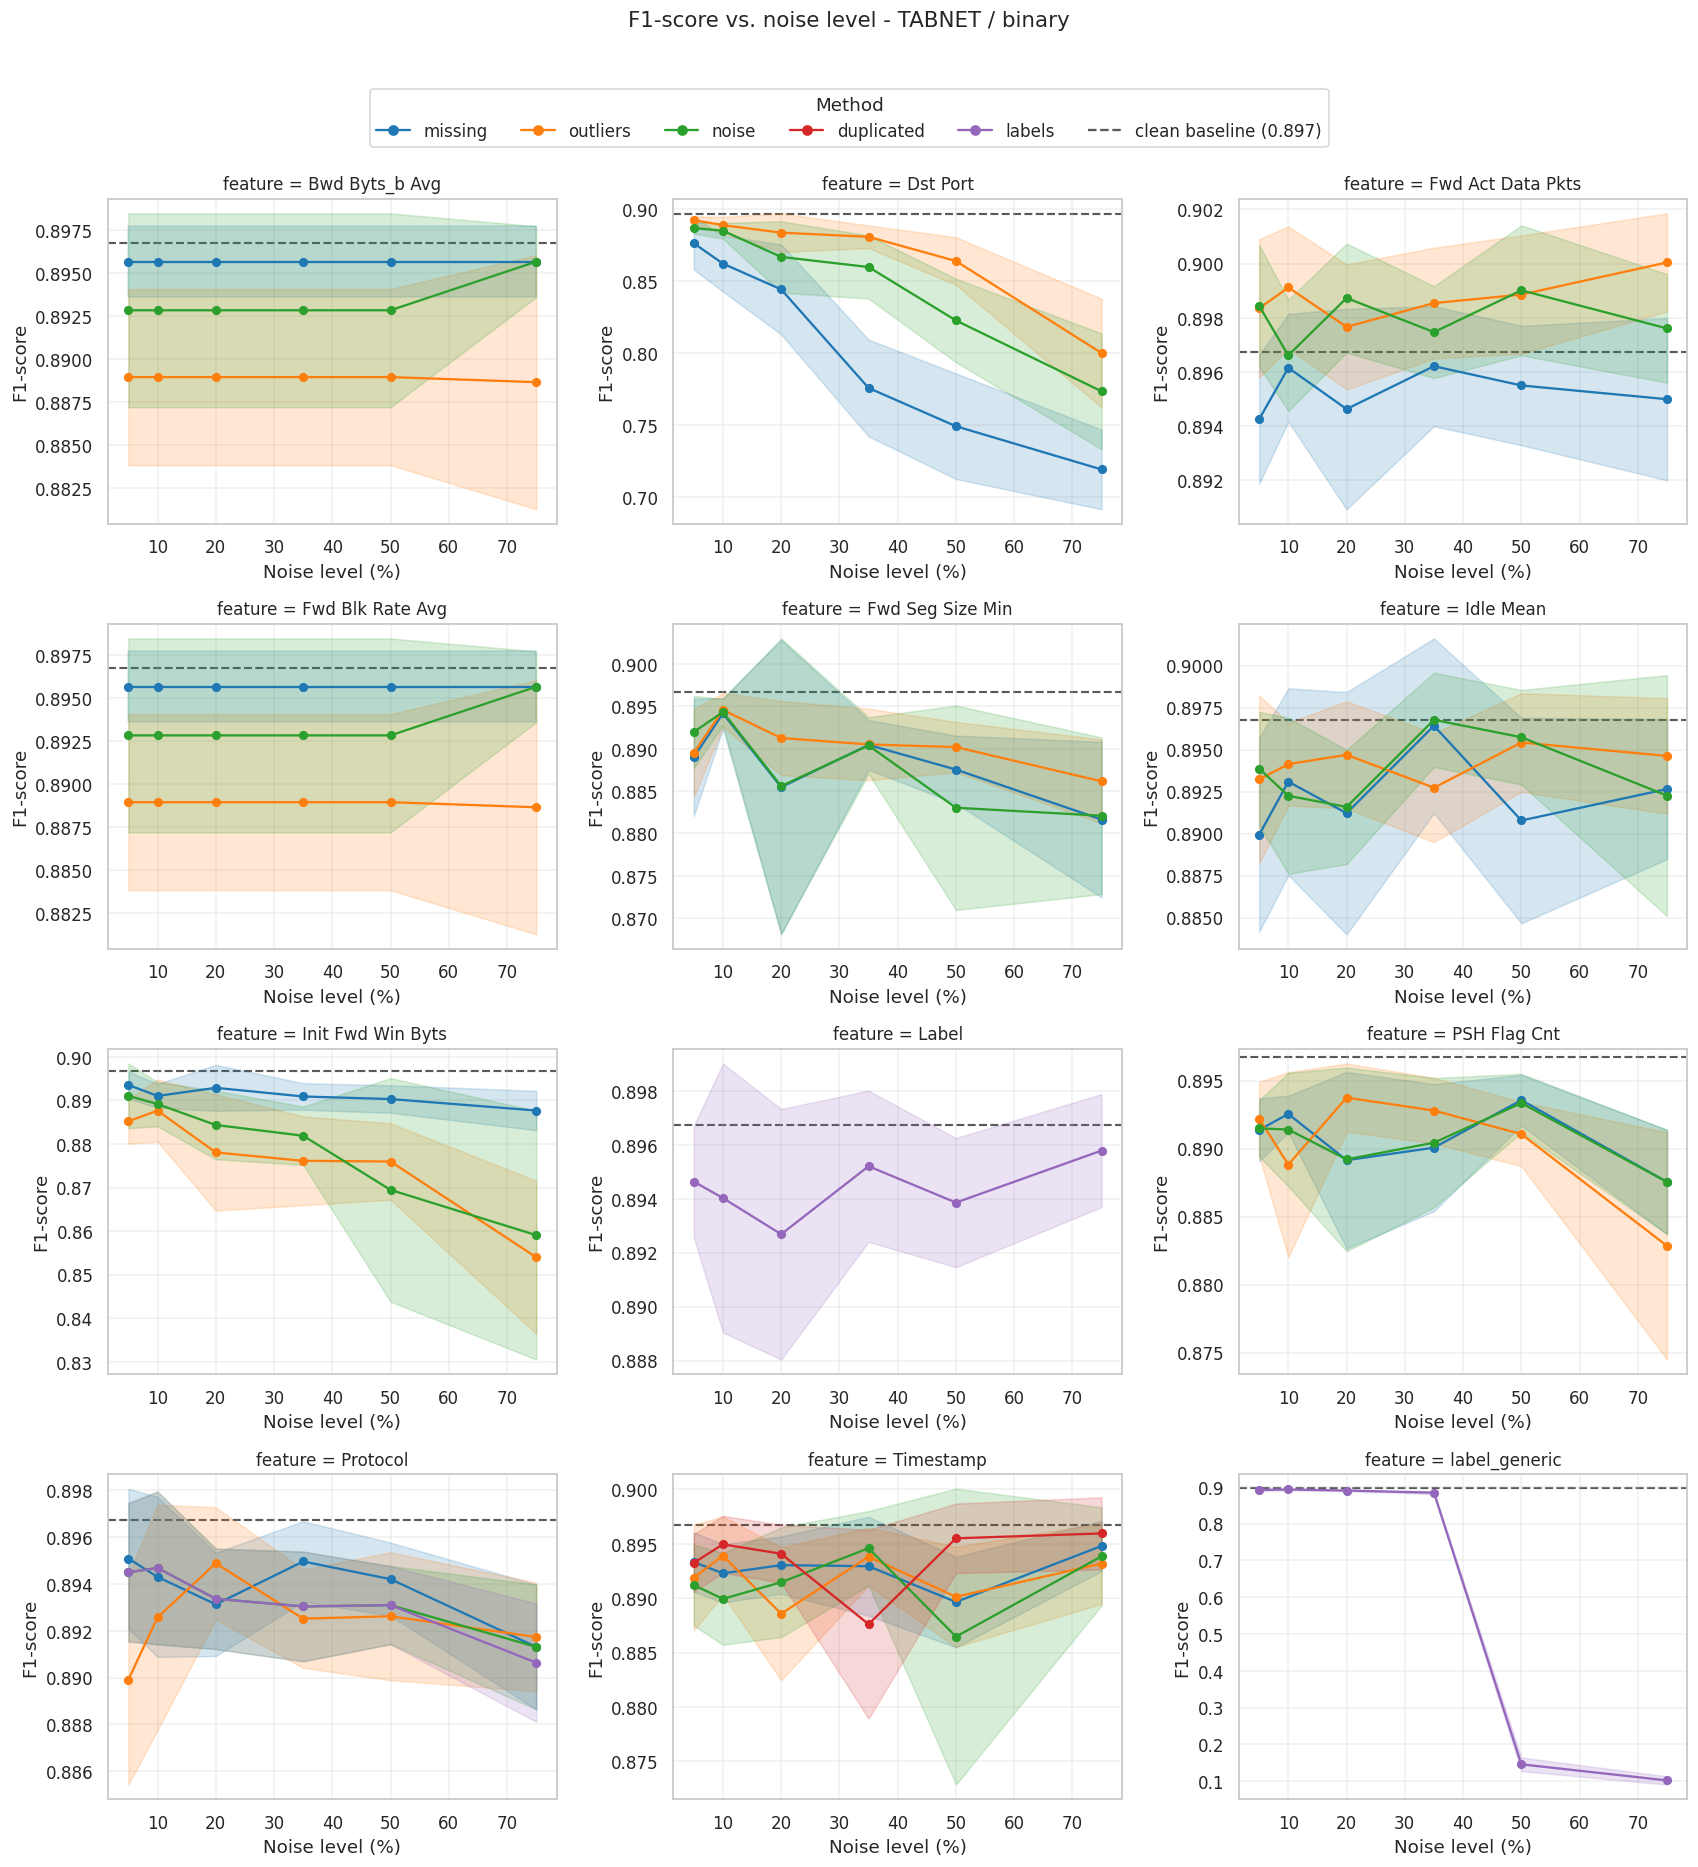

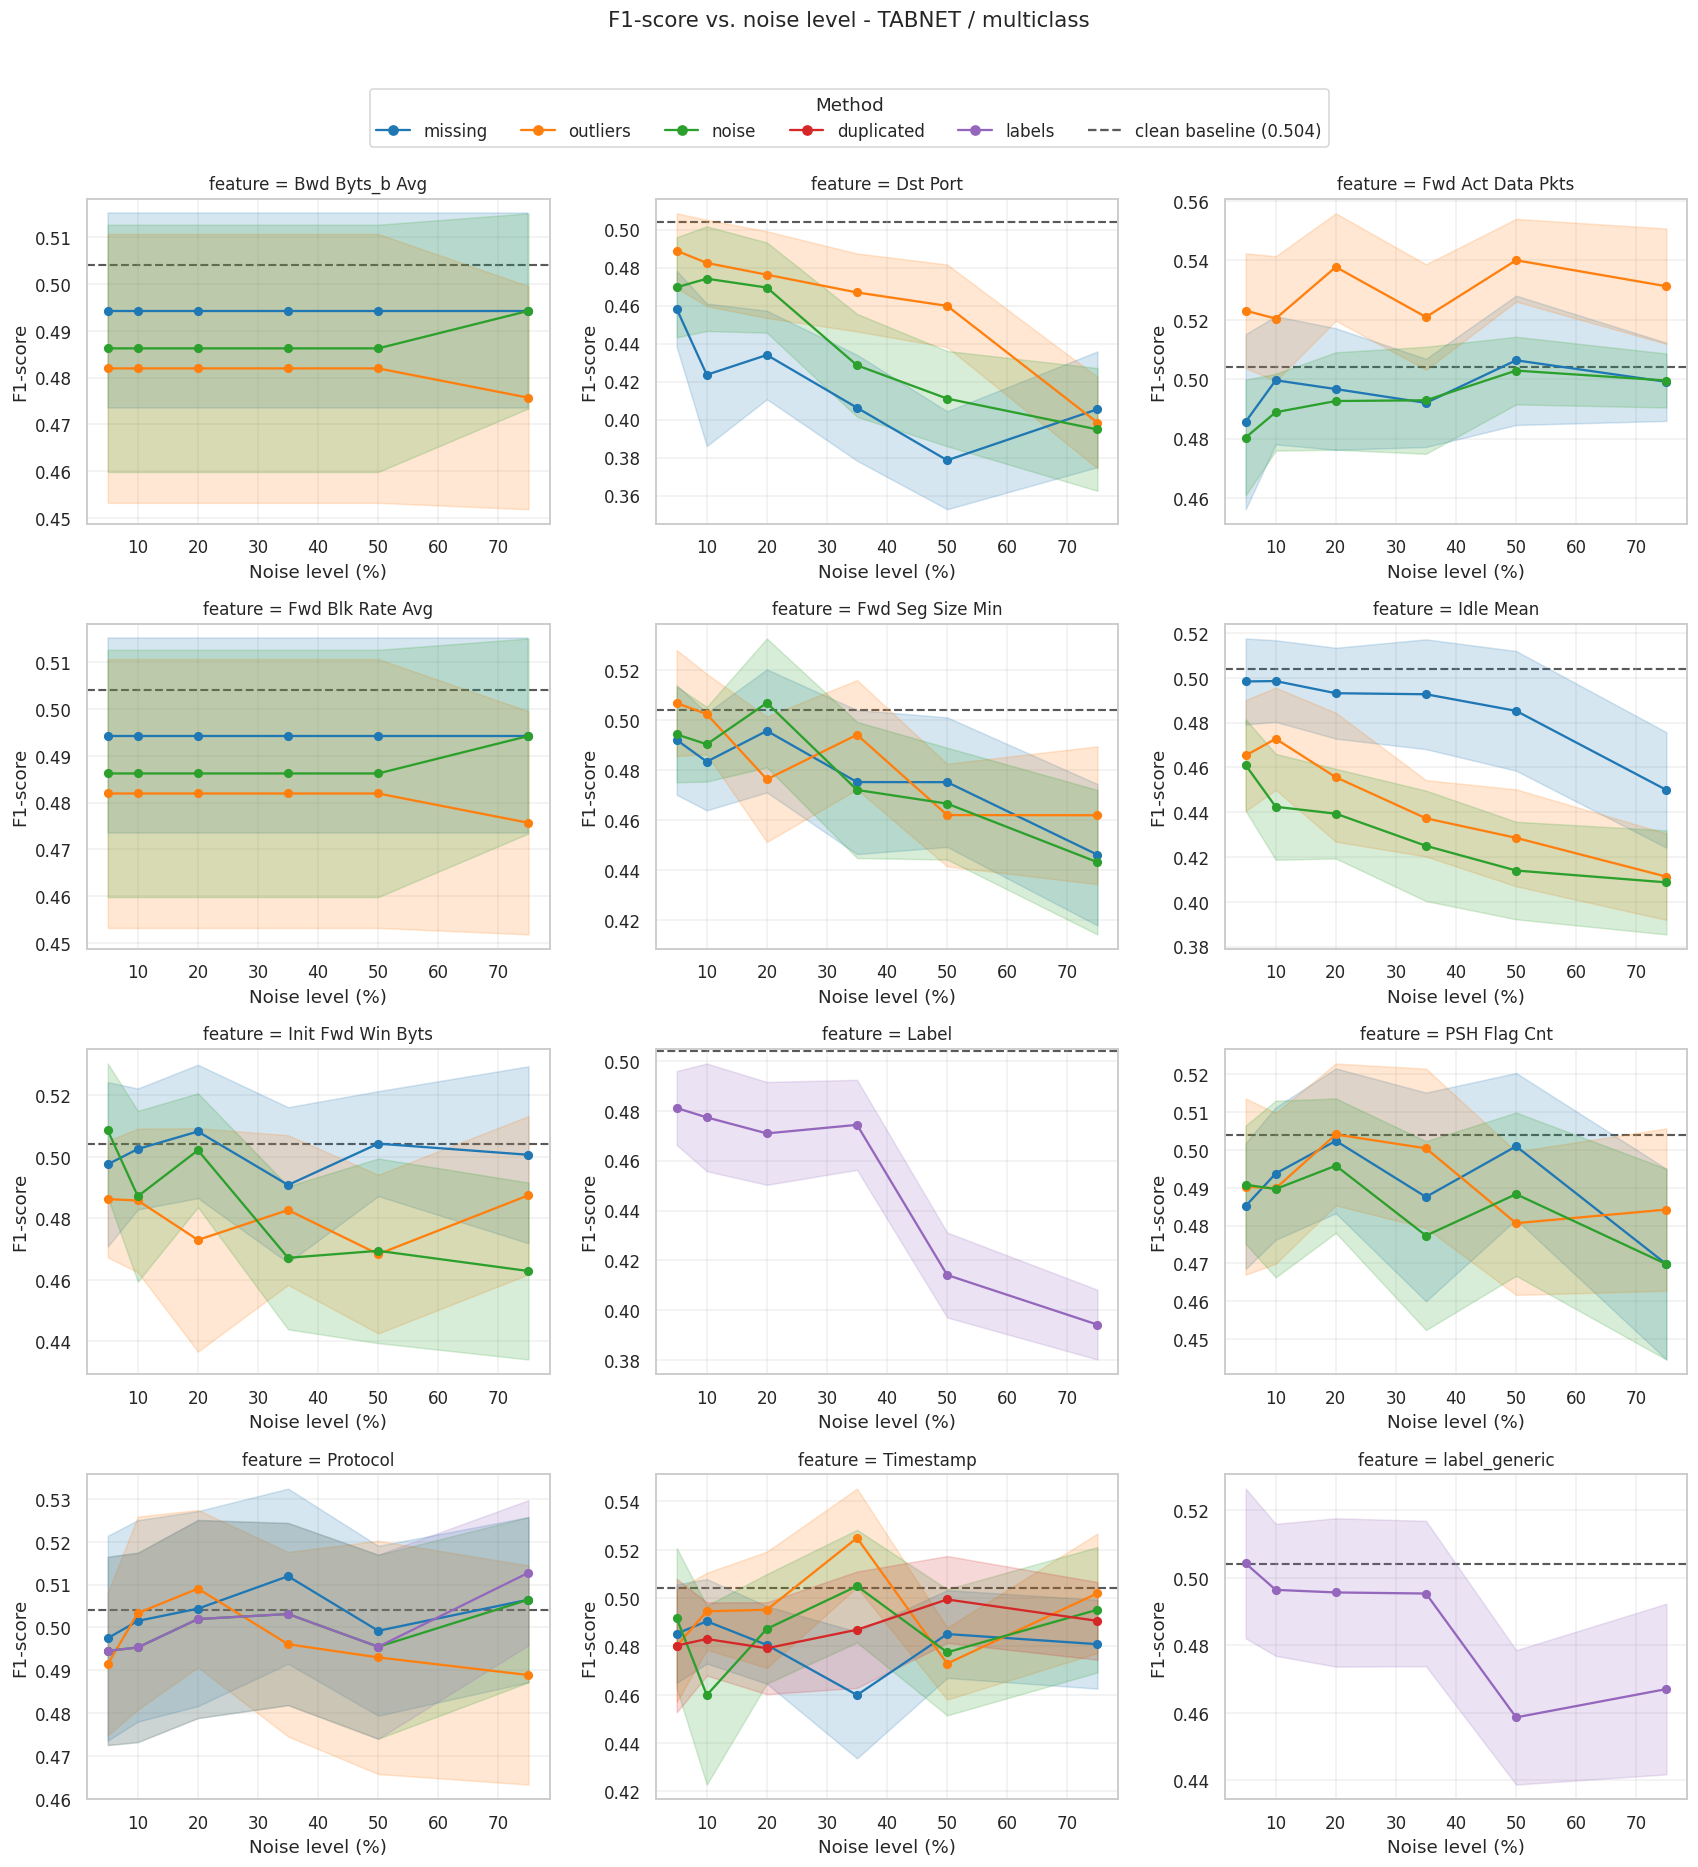

In [30]:
trend_figs("f1")

### Alternative view: one subplot per method, one line per feature

Swapping the facet and hue answers the dual question: *for a given corruption
method, which features are the most sensitive?* (shown for the binary task; edit
`task`/`metric` to explore).

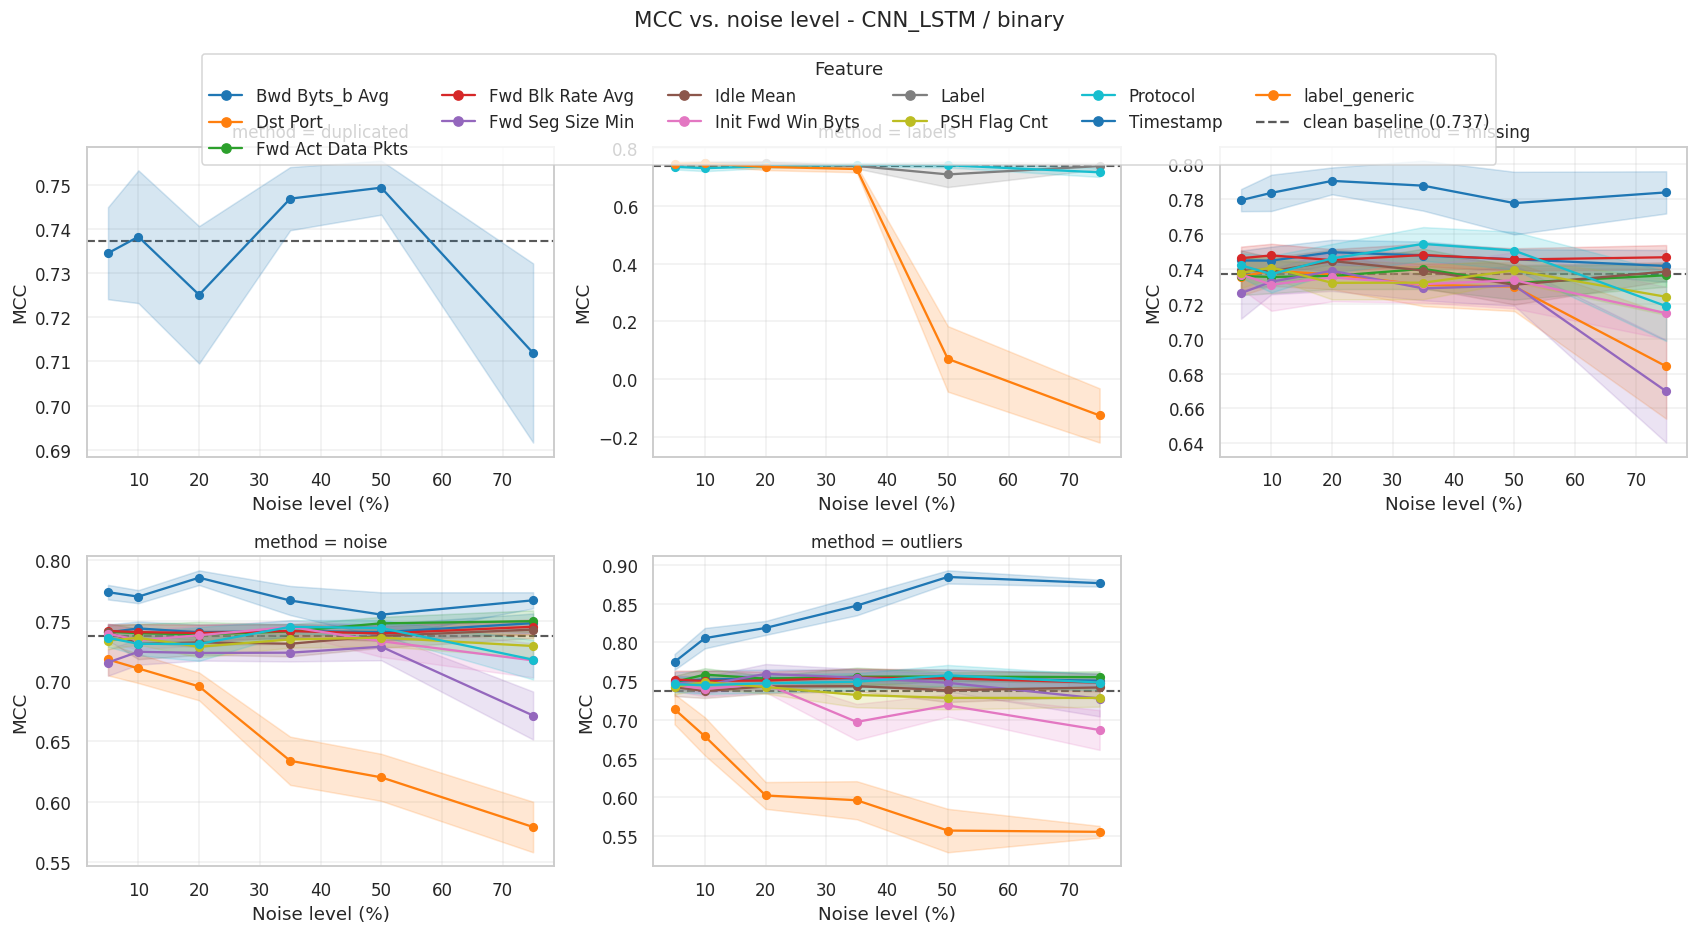

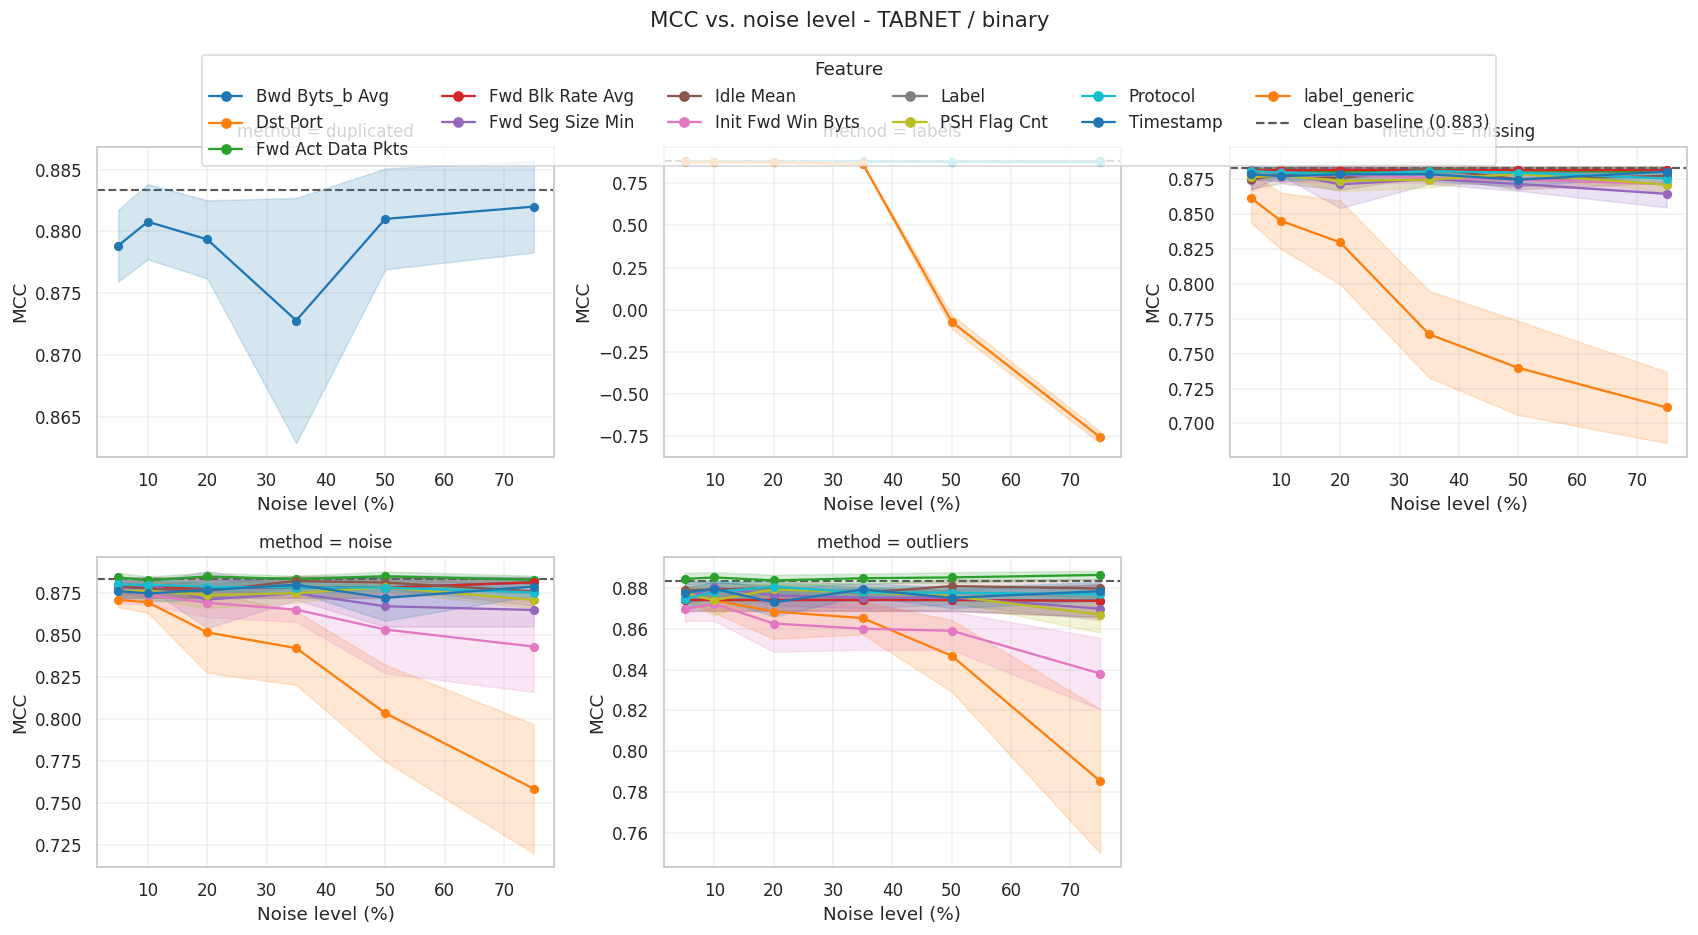

In [31]:
if HAS_DATA:
    for model in MODELS:
        fig = eu.plot_metric_vs_noise(df, model, "binary", "mcc",
                                      conf=CONF_LEVEL, facet_by="method",
                                      hue="feature", baselines=BL)
        if fig is not None:
            plt.show()

## 5. Heatmaps &mdash; method &times; noise level

Heatmaps condense the same information into compact, manuscript-friendly
figures. We show the **delta vs. the clean baseline** (diverging colour map
centred at zero): **blue = beats the clean model, red = worse than clean**. This
makes the "noise helped here" cells pop out at a glance.

> If the clean baseline is missing the function falls back to the lowest noise
> level as a proxy reference (`delta_vs_ref`).

Heatmaps show the change vs the CLEAN baseline (blue = beats clean).


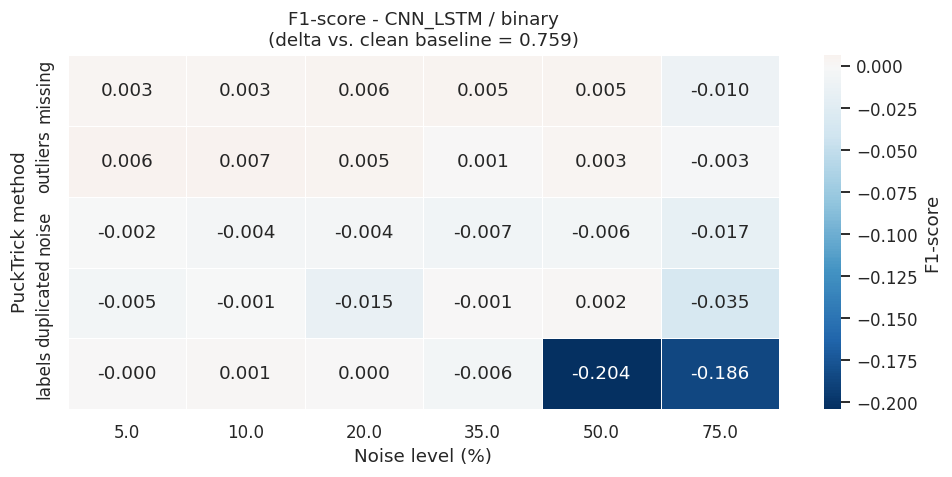

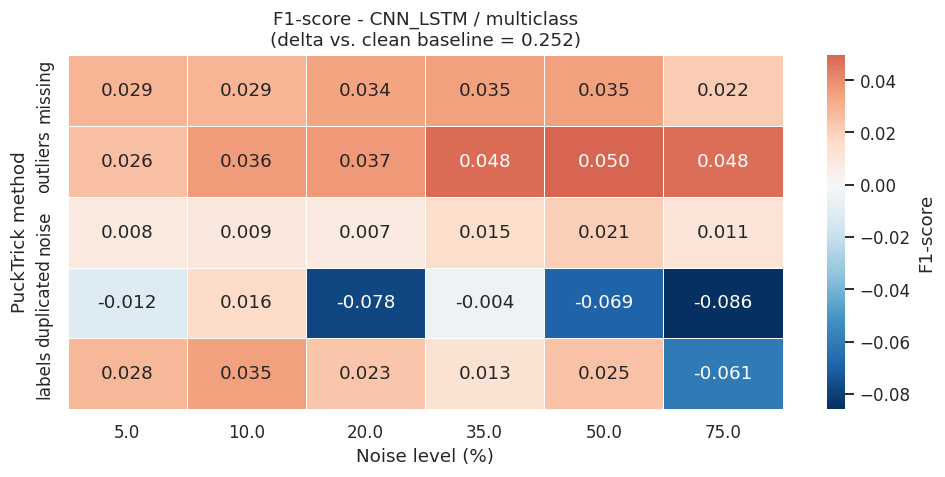

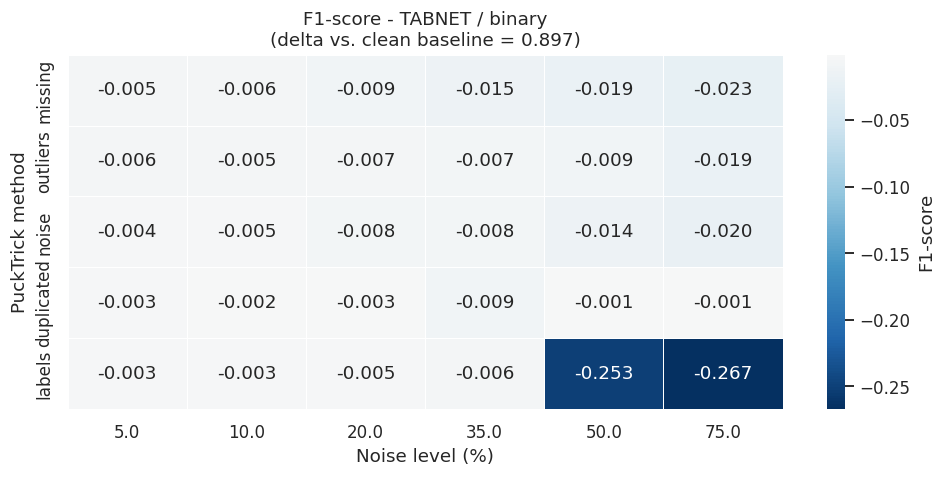

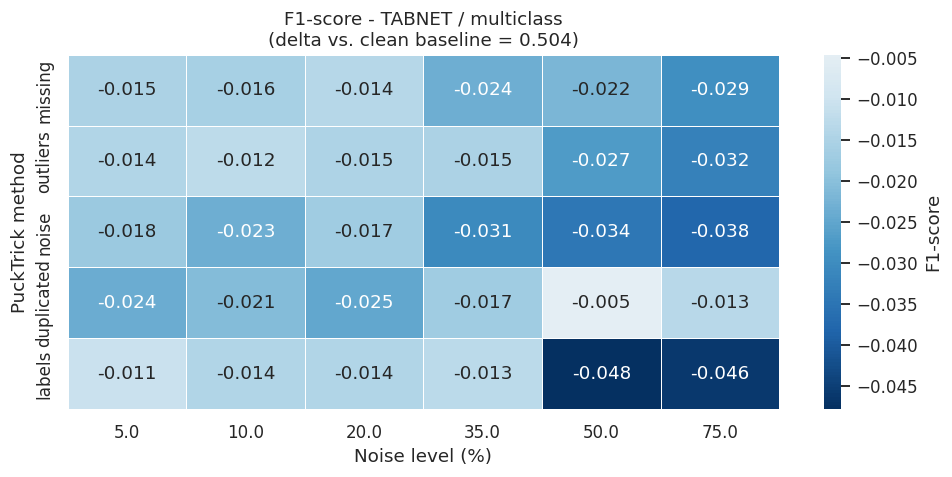

In [42]:
if HAS_DATA:
    if HAS_BASELINE:
        print("Heatmaps show the change vs the CLEAN baseline (blue = beats clean).")
    else:
        ref = eu.reference_level(df)
        print(f"No clean baseline; using lowest noise level {ref:g}% as proxy reference.")
    for model in MODELS:
        for task in TASKS:
            fig = eu.plot_metric_heatmap(df, model, task, "f1",
                                         delta_vs_baseline=HAS_BASELINE, baselines=BL,
                                         delta_vs_ref=not HAS_BASELINE)
            if fig is not None:
                plt.show()

## 6. Is the change real? &mdash; significance tests

Overlapping error bars are not a verdict. We run **two complementary Wilcoxon
signed-rank tests**, both at the 5% level:

**(6a) vs. the clean baseline &mdash; the headline test.** For each
`(method, feature, noise%)` we test whether the per-seed metric values differ
from the **clean-baseline scalar** (one-sample Wilcoxon of `value - baseline`
against zero). This answers the thesis' core question directly: *does injecting
this noise beat (or hurt) the model trained on clean data?* The configurations
with `median_delta > 0` and `p < 0.05` are the defensible **"noise helped vs.
clean"** claims.

**(6b) vs. the lowest noise level &mdash; a within-grid trend check.** Pairs each
seed's metric with the *same seed's* metric at the lowest noise level. Pairing by
seed cancels seed-to-seed variance; it tells us whether *increasing* the noise
beyond the mildest setting moves the metric.

> With few seeds the test has limited power, so absence of significance is *not*
> evidence of no effect; always read it next to `n`.

In [33]:
# (6a) vs the CLEAN baseline -- the headline 'does noise beat clean?' test.
def baseline_significance(metric, task="binary"):
    if not (HAS_DATA and HAS_BASELINE):
        return pd.DataFrame()
    out = [eu.baseline_delta_significance(df, BL, m, task, metric) for m in MODELS]
    out = [o for o in out if not o.empty]
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

bsig_mcc = baseline_significance("mcc", task="binary")
if HAS_DATA and HAS_BASELINE and not bsig_mcc.empty:
    beats = bsig_mcc[(bsig_mcc["median_delta"] > 0) & (bsig_mcc["significant"])]
    print(f"Configurations that SIGNIFICANTLY BEAT the clean baseline "
          f"(binary MCC): {len(beats)} of {len(bsig_mcc)} tested")
    display(beats.sort_values("median_delta", ascending=False).reset_index(drop=True))
    print("\nConfigurations significantly WORSE than clean (for completeness):")
    worse = bsig_mcc[(bsig_mcc["median_delta"] < 0) & (bsig_mcc["significant"])]
    display(worse.sort_values("median_delta").head(20).reset_index(drop=True))
elif HAS_DATA and not HAS_BASELINE:
    print("No clean baseline available - skipping the vs-baseline test (see 6b).")

Configurations that SIGNIFICANTLY BEAT the clean baseline (binary MCC): 72 of 408 tested


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant
0,cnn_lstm,outliers,Timestamp,50.0,20,0.737344,0.886908,0.149564,0.146924,0.000002,True
1,cnn_lstm,outliers,Timestamp,75.0,20,0.737344,0.878107,0.140762,0.138934,0.000002,True
2,cnn_lstm,outliers,Timestamp,35.0,20,0.737344,0.847259,0.109914,0.109888,0.000002,True
3,cnn_lstm,outliers,Timestamp,20.0,20,0.737344,0.822167,0.084823,0.081163,0.000002,True
4,cnn_lstm,outliers,Timestamp,10.0,20,0.737344,0.813557,0.076213,0.067981,0.000004,True
...,...,...,...,...,...,...,...,...,...,...,...
67,cnn_lstm,missing,Bwd Byts_b Avg,5.0,19,0.737344,0.744835,0.007491,0.007487,0.019581,True
68,cnn_lstm,outliers,Fwd Seg Size Min,50.0,20,0.737344,0.744712,0.007367,0.010378,0.022757,True
69,cnn_lstm,noise,Protocol,50.0,20,0.737344,0.744388,0.007044,0.006506,0.033325,True
70,cnn_lstm,outliers,Protocol,75.0,20,0.737344,0.744231,0.006887,0.010732,0.025081,True



Configurations significantly WORSE than clean (for completeness):


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant
0,tabnet,labels,label_generic,75.0,20,0.883325,-0.789998,-1.673324,-1.642223,0.000002,True
1,tabnet,labels,label_generic,50.0,20,0.883325,-0.087508,-0.970833,-0.956013,0.000002,True
2,cnn_lstm,labels,label_generic,50.0,20,0.737344,-0.009252,-0.746596,-0.667817,0.000002,True
3,cnn_lstm,labels,label_generic,75.0,20,0.737344,0.000000,-0.737344,-0.863905,0.000051,True
4,cnn_lstm,outliers,Dst Port,50.0,20,0.737344,0.555128,-0.182216,-0.180226,0.000002,True
5,cnn_lstm,outliers,Dst Port,75.0,20,0.737344,0.555155,-0.182189,-0.181871,0.000002,True
6,tabnet,missing,Dst Port,75.0,20,0.883325,0.701538,-0.181787,-0.171905,0.000088,True
7,tabnet,missing,Dst Port,50.0,20,0.883325,0.705958,-0.177367,-0.143539,0.000088,True
8,cnn_lstm,noise,Dst Port,75.0,20,0.737344,0.564001,-0.173343,-0.158438,0.000002,True
9,cnn_lstm,outliers,Dst Port,35.0,20,0.737344,0.582651,-0.154693,-0.141108,0.000004,True


In [34]:
# (6b) vs the lowest noise level -- paired within-grid trend check.
def significance(metric, task="binary"):
    if not HAS_DATA:
        return pd.DataFrame()
    ref = eu.reference_level(df)
    out = []
    for model in MODELS:
        s = eu.paired_delta_significance(df, model, task, metric, ref)
        if not s.empty:
            s.insert(0, "model", model)
            out.append(s)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

sig_mcc = significance("mcc", task="binary")
if HAS_DATA and not sig_mcc.empty:
    ref = eu.reference_level(df)
    improved = sig_mcc[(sig_mcc["median_delta"] > 0) & (sig_mcc["significant"])]
    print(f"Significant MCC changes vs the {ref:g}% level (binary): "
          f"{len(improved)} improvements of {len(sig_mcc)} tested configs")
    display(improved.sort_values("median_delta", ascending=False).reset_index(drop=True))
elif HAS_DATA:
    print("Not enough paired data to run the within-grid test yet.")

Significant MCC changes vs the 5% level (binary): 17 improvements of 340 tested configs


,model,method,feature,noise_percentage,n_pairs,median_delta,mean_delta,p_value,significant
0,cnn_lstm,outliers,Timestamp,50.0,20,0.108051,0.109622,0.000002,True
1,cnn_lstm,outliers,Timestamp,75.0,20,0.105696,0.101632,0.000002,True
2,cnn_lstm,outliers,Timestamp,35.0,20,0.065791,0.072586,0.000002,True
3,cnn_lstm,outliers,Timestamp,20.0,20,0.041386,0.043862,0.000006,True
4,cnn_lstm,outliers,Timestamp,10.0,20,0.022372,0.030679,0.000483,True
5,cnn_lstm,noise,Fwd Seg Size Min,50.0,20,0.014918,0.013091,0.022757,True
6,cnn_lstm,outliers,Protocol,50.0,20,0.013425,0.011569,0.027607,True
7,cnn_lstm,duplicated,Timestamp,50.0,20,0.012447,0.014819,0.033325,True
8,cnn_lstm,missing,Fwd Seg Size Min,20.0,20,0.012337,0.012830,0.016871,True
9,cnn_lstm,noise,Timestamp,20.0,14,0.011124,0.012007,0.013128,True


## 7. Model comparison &mdash; TabNet vs. CNN-LSTM

Two complementary robustness summaries, averaged over all features/methods:

* **Mean metric across the whole noise grid** &mdash; overall quality under noise;
* **Degradation slope** &mdash; the linear trend of the metric vs. noise level
  (slope &approx; 0 &rarr; robust; strongly negative &rarr; fragile; positive
  &rarr; noise tends to help).

In [35]:
if HAS_DATA:
    rows = []
    for model in MODELS:
        for task in TASKS:
            sub = df[(df.model == model) & (df.task == task)]
            for metric in ["mcc", "f1"]:
                per_level = (sub.groupby("noise_percentage")[metric]
                               .mean().reset_index().dropna())
                slope = np.nan
                if len(per_level) >= 2:
                    slope = np.polyfit(per_level["noise_percentage"],
                                       per_level[metric], 1)[0]
                rows.append({"model": model, "task": task, "metric": metric,
                             "mean_over_grid": sub[metric].mean(),
                             "slope_per_pct": slope})
    comp = pd.DataFrame(rows)
    display(comp.pivot_table(index=["task", "metric"], columns="model",
                             values=["mean_over_grid", "slope_per_pct"]))

mean_over_grid           slope_per_pct          
model                   cnn_lstm    tabnet      cnn_lstm    tabnet
task       metric                                                 
binary     f1           0.752726  0.879453     -0.000435 -0.000587
           mcc          0.729126  0.859528     -0.000634 -0.000923
multiclass f1           0.276928  0.481911     -0.000039 -0.000279
           mcc          0.619482  0.820500     -0.000592 -0.000233

## 8. Per-class behaviour (multiclass)

The macro MCC/F1 can mask what happens to individual **attack classes**, some
of which are rare. The artifacts do not store a per-class report, but they do
store the multiclass confusion matrix (`cm_mul`), from which per-class
precision/recall/F1 follow directly. Here we check which classes gain or lose F1
as noise increases &mdash; important because an IDS that improves overall while
collapsing on a rare-but-critical attack is *not* an improvement in practice.
(Classes are identified by integer index, since names are not stored.)

In [36]:
pcd = eu.per_class_dataframe(ROOT_DIR)
if pcd.empty:
    print("No per-class data available yet.")
else:
    ref = eu.reference_level(df)
    hi = sorted(pcd["noise_percentage"].dropna().unique())[-1]
    piv = (pcd[pcd["noise_percentage"].isin([ref, hi])]
           .groupby(["model", "class", "noise_percentage"])["f1"].mean()
           .unstack("noise_percentage"))
    if ref in piv.columns and hi in piv.columns:
        piv["delta(F1)"] = piv[hi] - piv[ref]
        piv = piv.rename(columns={ref: f"F1@{ref:g}%", hi: f"F1@{hi:g}%"})
        print(f"Per-class F1 (mean over methods/features): reference {ref:g}% -> highest {hi:g}% noise")
        display(piv.sort_values("delta(F1)").round(4))

Per-class F1 (mean over methods/features): reference 5% -> highest 75% noise


noise_percentage   F1@5%  F1@75%  delta(F1)
model    class                             
cnn_lstm 3        0.7943  0.7327    -0.0617
         1        0.8080  0.7658    -0.0422
         6        0.4645  0.4362    -0.0283
tabnet   9        0.5349  0.5144    -0.0205
         1        0.9872  0.9715    -0.0157
         4        0.9842  0.9697    -0.0145
         2        0.5865  0.5788    -0.0077
         3        0.8890  0.8826    -0.0064
         10       0.6088  0.6032    -0.0057
cnn_lstm 0        0.9604  0.9556    -0.0048
tabnet   5        0.7271  0.7240    -0.0030
         0        0.9802  0.9780    -0.0022
         8        0.5857  0.5843    -0.0014
         11       0.7495  0.7559     0.0064
         6        0.6384  0.6450     0.0065
cnn_lstm 8        0.6882  0.7036     0.0154
tabnet   7        0.0143  0.0490     0.0347
cnn_lstm 5        0.3749  0.4359     0.0610
         9        0.1627  0.2266     0.0639
         2        0.0651  0.1748     0.1097
         4        0.1061  0.2579     0.1518
         10       0.1415  0.3255     0.1840
         11       0.5158  0.7348     0.2191
         7           NaN  0.1037        NaN
         12          NaN     NaN        NaN
         13          NaN     NaN        NaN
tabnet   12          NaN     NaN        NaN
         13          NaN     NaN        NaN
         14          NaN     NaN        NaN

## 9. Feature-importance drift

A mechanistic check: when PuckTrick corrupts a feature, does the model's
**permutation importance** for that feature drop (it learns to ignore the
unreliable signal) or stay high (it keeps relying on noise)? We track the mean
importance of the *corrupted* feature as the noise level grows. (`is_corrupted`
is name-normalised, so the file's `Down_Up Ratio` matches the importance dict's
`Down/Up Ratio`.)

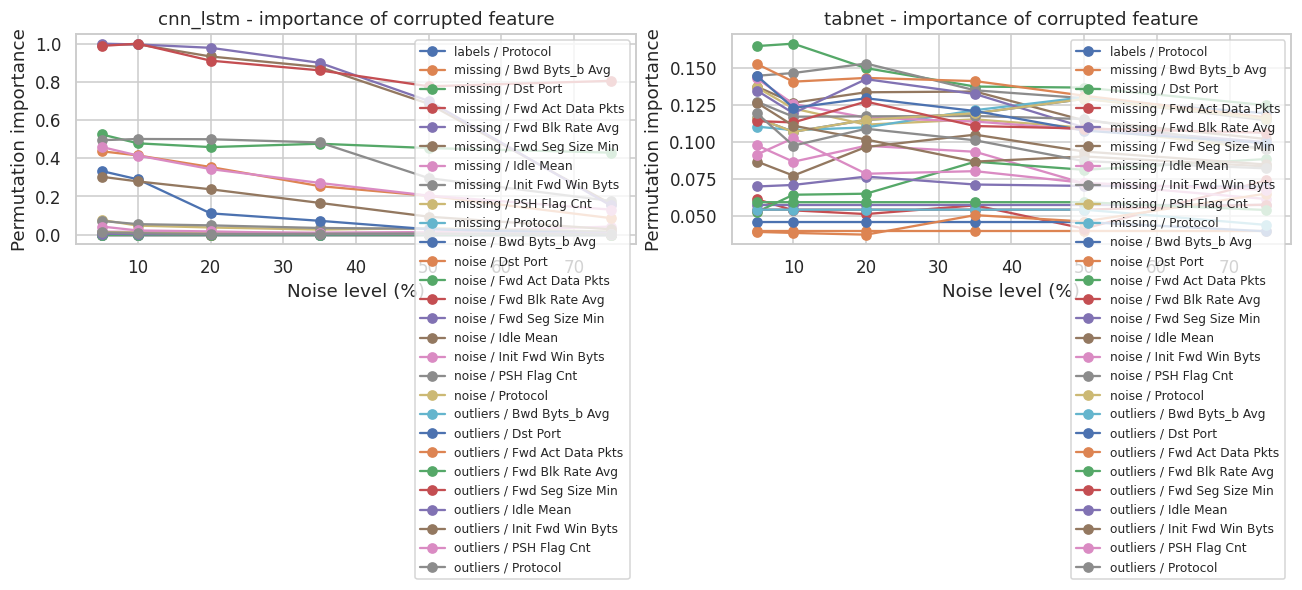

In [37]:
fid = eu.feature_importance_dataframe(ROOT_DIR)
if fid.empty:
    print("No feature-importance data available yet.")
else:
    self_imp = fid[fid["is_corrupted"]]
    if self_imp.empty:
        print("Corrupted feature not found among reported importances "
              "(e.g. row-level 'duplicated'/'labels' runs); showing top features instead.")
        top = (fid.groupby(["model", "fi_feature"])["importance"].mean()
                  .reset_index().sort_values("importance", ascending=False))
        display(top.groupby("model").head(8).reset_index(drop=True))
    else:
        tab = (self_imp.groupby(["model", "method", "corrupted_feature",
                                 "noise_percentage"])["importance"]
                       .mean().reset_index())
        models_here = sorted(tab["model"].dropna().unique())
        fig, axes = plt.subplots(1, len(models_here),
                                 figsize=(6 * len(models_here), 4.2), squeeze=False)
        for ax, model in zip(axes[0], models_here):
            for (mth, feat), g in tab[tab.model == model].groupby(["method", "corrupted_feature"]):
                g = g.sort_values("noise_percentage")
                ax.plot(g["noise_percentage"], g["importance"], marker="o",
                        label=f"{mth} / {feat}")
            ax.set_title(f"{model} - importance of corrupted feature")
            ax.set_xlabel("Noise level (%)"); ax.set_ylabel("Permutation importance")
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

## 10. Export for the thesis

Aggregated tables are written to CSV under `RESULTS_DIR` so they can be pulled
straight into the LaTeX sources in `temp-latex` (e.g. with `pandas.to_latex` or
`pgfplots`). Re-running regenerates them from whatever is currently on disk.

In [38]:
if HAS_DATA:
    for metric in ["mcc", "f1", "accuracy"]:
        eu.export_aggregate(df, metric, RESULTS_DIR, conf=CONF_LEVEL)
    if not sig_mcc.empty:
        sig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_lownoise.csv"),
                       index=False)
        print("[export] significance_mcc_binary_vs_lownoise.csv")
    if HAS_BASELINE and not bsig_mcc.empty:
        bsig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_baseline.csv"),
                        index=False)
        print("[export] significance_mcc_binary_vs_baseline.csv")
    if HAS_BASELINE:
        BL.to_csv(os.path.join(RESULTS_DIR, "baseline_metrics.csv"), index=False)
        print("[export] baseline_metrics.csv")
    print("\nExports written to:", RESULTS_DIR)

[export] mcc: 816 rows -> evaluation_results/Experiment_B/aggregate_mcc.csv
[export] f1: 816 rows -> evaluation_results/Experiment_B/aggregate_f1.csv
[export] accuracy: 816 rows -> evaluation_results/Experiment_B/aggregate_accuracy.csv
[export] significance_mcc_binary_vs_lownoise.csv
[export] significance_mcc_binary_vs_baseline.csv
[export] baseline_metrics.csv

Exports written to: evaluation_results/Experiment_B


## 11. Auto-generated summary &amp; conclusions

A programmatic digest of the key numbers &mdash; a *starting point* for the
chapter's prose, recomputed every run so it never goes stale. Treat it as
scaffolding to be edited into academic English, not as final text.

In [39]:
def auto_summary():
    if not HAS_DATA:
        print("No data yet - nothing to summarise.")
        return
    ref = eu.reference_level(df)
    lines = []
    lines.append(f"Experiment {PHASE} - automatic evaluation summary")
    lines.append("=" * 60)
    lines.append(f"Runs parsed        : {len(df)//2} artifacts "
                 f"({df['seed'].nunique()} seeds, models={sorted(df['model'].dropna().unique())})")
    if HAS_BASELINE:
        for model in sorted(BL['model'].dropna().unique()):
            bv = eu.baseline_value(BL, model, 'binary', 'mcc')
            lines.append(f"Clean baseline MCC : {bv:.3f}  ({model}, binary)")
    else:
        lines.append(f"Reference level    : {ref:g}% (no clean baseline on disk; proxy)")

    bb = eu.aggregate_with_ci(df[df.task == 'binary'],
                              ['model','method','feature','noise_percentage'], 'mcc')
    if not bb.empty:
        top = bb.sort_values('mean', ascending=False).iloc[0]
        lines.append("")
        lines.append(f"Best binary MCC    : {top['mean']:.3f} "
                     f"({top['model']}, {top['method']} on {top['feature']} "
                     f"@ {top['noise_percentage']:g}%, n={int(top['n'])})")

    if HAS_BASELINE:
        n_beat = 0
        for model in df['model'].dropna().unique():
            s = eu.baseline_delta_significance(df, BL, model, 'binary', 'mcc')
            if not s.empty:
                n_beat += int(((s['median_delta'] > 0) & s['significant']).sum())
        lines.append(f"Beat clean baseline: {n_beat} (model x method x feature x level) "
                     f"configurations significantly beat clean (Wilcoxon p<0.05)")
    n_imp = 0
    for model in df['model'].dropna().unique():
        s = eu.paired_delta_significance(df, model, 'binary', 'mcc', ref)
        if not s.empty:
            n_imp += int(((s['median_delta'] > 0) & s['significant']).sum())
    lines.append(f"Sig. vs {ref:g}% level : {n_imp} configs improve over the lowest noise level")
    print("\n".join(lines))

auto_summary()

Experiment B - automatic evaluation summary
Runs parsed        : 8082 artifacts (20 seeds, models=['cnn_lstm', 'tabnet'])
Clean baseline MCC : 0.737  (cnn_lstm, binary)
Clean baseline MCC : 0.883  (tabnet, binary)

Best binary MCC    : 0.886 (tabnet, outliers on Fwd Act Data Pkts @ 75%, n=20)
Beat clean baseline: 72 (model x method x feature x level) configurations significantly beat clean (Wilcoxon p<0.05)
Sig. vs 5% level : 17 configs improve over the lowest noise level


---

### Caveats to carry into the write-up

* **Clean baseline is a single deterministic run** (no seeds), so the
  vs-baseline test (6a) is a one-sample Wilcoxon over the noisy config's seed
  distribution against a fixed clean value &mdash; the primary "noise beats
  clean" evidence for the thesis.
* **Single- vs. multiple-feature scenarios** are aggregated together by default.
  Filter `df[df.scenario == "single"]` (or `"multi"`) before any section to
  analyse them separately; the multiple-feature scenario is still in progress.
* As seeds accumulate toward the full 20, re-run the notebook periodically &mdash;
  the confidence intervals will tighten and previously non-significant effects
  may cross into significance.